# Week 5 — Machine-Learning Prediction and Chronological Updating

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/05/week5_main.ipynb)

The course repository is public. If the direct Colab link is temporarily unavailable, download `week5_main.ipynb` from GitHub and upload the file to Colab.

This is the complete Week 5 lesson. It defines a one-step-ahead financial prediction problem, fits an interpretable least-squares model using only historically permitted rows, compares it with transparent prediction baselines on common target dates, and then separates fixed, expanding, rolling, and walk-forward evaluation from model-refit, signal-update, and portfolio-rebalance schedules.

Each issue first uses fixed artificial data and then a source-grounded example from one recorded AAPL request. The AAPL examples demonstrate target construction, historical estimation, baselines, update schedules, and gross pre-cost decision accounting under stated conditions. They do not document stable predictive ability, profitable execution, or future investment performance. Week 4's signal-to-position boundary remains in force. Week 6 will add transaction costs and common financial benchmarks.

## Core financial question

How can a prediction model be estimated and updated through historical time without using an outcome, preprocessing parameter, or model choice that was unavailable at the stated prediction date?

Run the notebook from top to bottom. Keep both predictions for every issue, inspect the visible outputs, and answer two questions with a concrete decision and supporting evidence. Greater model complexity is not treated as stronger evidence.

## Observable outcome

After completing Week 5, you will produce a chronological prediction table. Every prediction will identify its target date, permitted training rows, preprocessing boundary, model version, training-row count, last training feature date, and last observed training outcome. The table will compare a least-squares model with zero and historical-mean prediction baselines on exactly the same targets, then show how expanding and rolling windows, refit frequency, signal-update frequency, and portfolio-rebalance frequency change different objects.

## Learning objectives

After completing Week 5, you should be able to:

- define a prediction target, horizon, feature time, prediction time, and outcome-availability time;
- distinguish a chronological fixed split from an invalid random reconstruction of historical decisions;
- fit an interpretable least-squares prediction model without using the current or later target;
- fit preprocessing only on the permitted training rows and preserve a transparent baseline comparison;
- implement fixed, expanding, rolling, and walk-forward designs on common target dates;
- distinguish model retraining, signal recalculation, and portfolio rebalancing; and
- freeze model, window, threshold, and update choices before opening the final test period.

## Before you begin

Complete Week 4 or be able to verify the relation between signal time, next position, and return interval. Use Google Colab or a local Jupyter environment with Python, `numpy`, `pandas`, `matplotlib`, and `yfinance`. Controlled examples use embedded values; source-grounded examples require internet access when executed.

Each issue contains a concept, a narrow source or research connection, two checkable predictions, two focused code examples with visible outputs, interpretations tied to displayed values, and two discussion questions. Common troubleshooting and completion evidence appear once near the end.

# Navigation through the twenty issues

| Section | Issues | Main decision | Evidence carried forward |
|---|---:|---|---|
| Prediction question and time | 1–3 | What is predicted, from which information, and when does the target become observable? | Target definition and availability table |
| Historical evaluation boundary | 4–5 | Which earlier rows may train a model, and why can a random split misrepresent the decision sequence? | Fixed chronological split and rejected random ordering |
| Model and baselines | 6–11 | How are the modeling table, least-squares model, preprocessing, baselines, and common-date metrics constructed? | Fixed-split predictions and prediction-only comparison |
| Expanding, rolling, and walk-forward designs | 12–14 | How does the permitted training sample change at each prediction date? | Historical predictions with recorded training boundaries |
| Separate update decisions | 15–18 | When do parameters, signals, positions, and model records change? | Versioned model, signal, and position histories |
| Protected evaluation and integrated claims | 19–20 | Which choices are frozen, and what can the artificial evidence support? | Frozen design and limited conclusion |

```text
point-in-time features at t
        ↓ model fitted only with outcomes observable by t
prediction for a later return
        ↓ threshold applied on a permitted signal-update date
signal after the t boundary
        ↓ Week 4 lag and rebalance permission
position for a later return interval
```

Prediction metrics describe the model output. They are not substitutes for Week 6 net financial results or Week 7 risk and uncertainty evidence.

# Preparation and information to record

The required prediction target is the next artificial one-session simple return. Features are five-session momentum and twenty-return trailing volatility, both available after the current artificial close. A prediction is calculated after that same close. The target becomes observable only after the next return interval ends.

Complete this record once for Case 4:

```text
Prediction target, horizon, unit, and target date:
Feature columns and availability time:
Prediction time:
Minimum training rows:
Window type and length:
Preprocessing fit boundary:
Model and baseline definitions:
Model-refit rule:
Signal-update rule:
Portfolio-rebalance rule and Week 4 lag:
Training, validation, and frozen test periods:
Choices frozen before the final test:
One prediction conclusion supported:
One investment conclusion not supported:
```

When the common course dataset is approved, add its provider, field definitions, release times, market calendar, allowed redistribution, and exact period boundaries. Do not replace the artificial data silently.

In [1]:
from importlib.metadata import PackageNotFoundError, version
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import yfinance as yf
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 28)
pd.set_option("display.width", 160)
plt.rcParams.update(
    {
        "figure.figsize": (7.6, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

US_HISTORY_REQUEST = {
    "start": "2023-01-03",
    "end": "2025-01-03",
    "interval": "1d",
    "auto_adjust": False,
    "actions": False,
    "progress": False,
    "threads": False,
    "multi_level_index": False,
}
FEATURE_COLUMNS = ["momentum_5", "volatility_20"]
TARGET_COLUMN = "target_next_return"
_US_HISTORY_CACHE = {}


def load_us_daily(symbol):
    # Return a copy of one fixed response without displaying all downloaded rows.
    if yf is None:
        raise ModuleNotFoundError("Install yfinance before running a source-grounded Week 5 example.")
    if symbol not in _US_HISTORY_CACHE:
        rows = yf.download(tickers=symbol, **US_HISTORY_REQUEST)
        if isinstance(rows.columns, pd.MultiIndex):
            rows.columns = rows.columns.get_level_values(0)
        rows.index = pd.DatetimeIndex(rows.index).tz_localize(None)
        required = {"Open", "High", "Low", "Close", "Volume"}
        if rows.empty or not required.issubset(rows.columns):
            raise ValueError(f"The recorded {symbol} request returned no usable OHLCV response.")
        rows = rows.sort_index()
        if not rows.index.is_unique:
            raise ValueError(f"The recorded {symbol} response contains duplicate dates.")
        _US_HISTORY_CACHE[symbol] = rows
    return _US_HISTORY_CACHE[symbol].copy()


def next_stored_date(index, current_date):
    position = index.get_loc(current_date)
    if position + 1 >= len(index):
        raise IndexError("No later stored date is available for this target endpoint.")
    return index[position + 1]


def build_prediction_table(symbol="AAPL"):
    rows = load_us_daily(symbol)
    raw = rows[["Close"]].copy()
    raw["asset_return"] = raw["Close"].pct_change(fill_method=None)
    raw["momentum_5"] = raw["Close"] / raw["Close"].shift(5) - 1
    raw["volatility_20"] = raw["asset_return"].rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
    raw[TARGET_COLUMN] = raw["asset_return"].shift(-1)
    model = raw[FEATURE_COLUMNS + [TARGET_COLUMN]].dropna().copy()
    return raw, model


def fit_least_squares(training_frame):
    x = np.column_stack([np.ones(len(training_frame)), training_frame[FEATURE_COLUMNS].to_numpy()])
    y = training_frame[TARGET_COLUMN].to_numpy()
    coefficients, residuals, rank, singular_values = np.linalg.lstsq(x, y, rcond=None)
    return {"coefficients": coefficients, "residuals": residuals, "rank": int(rank), "singular_values": singular_values}


def predict_least_squares(frame, coefficients):
    x = np.column_stack([np.ones(len(frame)), frame[FEATURE_COLUMNS].to_numpy()])
    return x @ coefficients


def mean_squared_error(outcome, prediction):
    outcome_values = np.asarray(outcome, dtype=float)
    prediction_values = np.asarray(prediction, dtype=float)
    if outcome_values.shape != prediction_values.shape:
        raise ValueError("Outcome and prediction must use the same number of target rows.")
    return float(np.mean((outcome_values - prediction_values) ** 2))


def walk_forward_real(raw, frame, minimum_train=80, window=None, refit_every=5):
    if minimum_train < 2 or refit_every < 1:
        raise ValueError("minimum_train must be at least 2 and refit_every must be positive.")
    result = pd.DataFrame(index=frame.index)
    version = 0
    fitted = None
    for position in range(minimum_train, len(frame)):
        if fitted is None or (position - minimum_train) % refit_every == 0:
            history = frame.iloc[:position]
            if window is not None:
                history = history.iloc[-window:]
            feature_mean = history[FEATURE_COLUMNS].mean()
            feature_std = history[FEATURE_COLUMNS].std(ddof=1)
            standardized = (history[FEATURE_COLUMNS] - feature_mean) / feature_std
            x = np.column_stack([np.ones(len(history)), standardized.to_numpy()])
            coefficients, _, rank, _ = np.linalg.lstsq(x, history[TARGET_COLUMN].to_numpy(), rcond=None)
            if rank != len(FEATURE_COLUMNS) + 1:
                raise ValueError("The standardized training design is rank deficient.")
            version += 1
            fitted = {
                "coefficients": coefficients,
                "feature_mean": feature_mean,
                "feature_std": feature_std,
                "training_rows": len(history),
                "first_training_feature_date": history.index[0],
                "last_training_feature_date": history.index[-1],
                "last_training_target_end_date": next_stored_date(raw.index, history.index[-1]),
            }
        current_standardized = (frame.iloc[position][FEATURE_COLUMNS] - fitted["feature_mean"]) / fitted["feature_std"]
        prediction = float(np.r_[1.0, current_standardized.to_numpy()] @ fitted["coefficients"])
        row = frame.index[position]
        result.loc[row, "prediction"] = prediction
        result.loc[row, "model_version"] = version
        result.loc[row, "training_rows"] = fitted["training_rows"]
        result.loc[row, "first_training_feature_date"] = fitted["first_training_feature_date"]
        result.loc[row, "last_training_feature_date"] = fitted["last_training_feature_date"]
        result.loc[row, "last_training_target_end_date"] = fitted["last_training_target_end_date"]
        result.loc[row, "intercept"] = fitted["coefficients"][0]
        result.loc[row, "momentum_coefficient"] = fitted["coefficients"][1]
        result.loc[row, "volatility_coefficient"] = fitted["coefficients"][2]
        result.loc[row, "momentum_mean"] = fitted["feature_mean"]["momentum_5"]
        result.loc[row, "volatility_mean"] = fitted["feature_mean"]["volatility_20"]
        result.loc[row, "momentum_std"] = fitted["feature_std"]["momentum_5"]
        result.loc[row, "volatility_std"] = fitted["feature_std"]["volatility_20"]
    return result


def show_figure_with_alt_text(figure, alt_text):
    if not isinstance(alt_text, str) or not alt_text.strip():
        raise ValueError("Figure alternative text must be a nonempty string.")
    display(figure, metadata={"image/png": {"alt": alt_text.strip()}})
    plt.close(figure)


environment = pd.Series(
    {
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
        "yfinance": YFINANCE_VERSION,
    },
    name="Value",
)
display(environment.rename_axis("Environment item").to_frame())

,Value
Environment item,
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0


## Issue 1 — What financial outcome is the model asked to predict?


A prediction problem must name the outcome, holding horizon, unit, target date, feature time, and intended later decision. `Predict price` is incomplete because a price level, return, direction, and volatility are different outcomes.

Week 5 predicts the next artificial one-session simple return as a decimal. Features are available after the current close, and the target return ends at the next close. The model output will later be thresholded into a signal, but prediction quality and portfolio quality remain separate questions.

Let $P_t$ be the closing price in US dollars on feature date $t$. The one-session target stored on that row is

$$
y_t=R_{t,t+1}=\frac{P_{t+1}}{P_t}-1.
$$

$y_t$ is a dimensionless decimal return. It is not observable until the later Close $P_{t+1}$ is available.

The model does not predict profitability after costs. It predicts one numerical return under an artificial data-generating process.


### Connection to a documented source

The fixed AAPL request supplies dated prices from which a next-session Close-to-Close return can be calculated. The provider does not choose the target horizon, unit, prediction time, baseline, threshold, or later portfolio rule.

Sources: [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html); [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict which design fields change when the artificial target changes from return to direction. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [2]:
prediction_design = pd.DataFrame(
    [
        ("Outcome", "Next artificial one-session simple return"),
        ("Target unit", "Decimal return"),
        ("Feature time", "After close at feature date t"),
        ("Target interval", "Close at t to close at t+1"),
        ("Target observable", "After close at t+1"),
        ("Model output", "Numerical prediction of next return"),
        ("Later signal", "1 if prediction > 0; 0 otherwise; missing before prediction"),
        ("Unsupported claim", "Net profitability, execution quality, or future performance"),
    ],
    columns=["Design field", "Week 5 definition"],
)
display(prediction_design.style.hide(axis="index").set_caption("Week 5 financial prediction question"))
assert prediction_design["Design field"].is_unique

Design field,Week 5 definition
Outcome,Next artificial one-session simple return
Target unit,Decimal return
Feature time,After close at feature date t
Target interval,Close at t to close at t+1
Target observable,After close at t+1
Model output,Numerical prediction of next return
Later signal,1 if prediction > 0; 0 otherwise; missing before prediction
Unsupported claim,"Net profitability, execution quality, or future performance"


### Interpret Code 1


The target is a decimal return over one later interval, not a price level or a binary direction. A direction model would require a different target, loss function, baseline, and interpretation even if the feature dates were unchanged.

The unsupported-claim row is part of the design. A model can have a lower prediction error without producing a better position after thresholding, lagging, and later costs.


### Source-grounded example

Code 2 displays one usable AAPL feature date, the later target endpoint, and the decimal next-session return that the Week 5 model is asked to predict.

### Before Code 2

Predict the first usable AAPL feature date, its target end date, and whether the target is stored as a decimal return. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [3]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
feature_date = aapl_model.index[0]
target_end_date = next_stored_date(aapl_raw.index, feature_date)
real_target_definition = pd.DataFrame(
    [
        ("Symbol", "AAPL", "Requested security"),
        ("Feature date", str(feature_date.date()), "After the stored Close"),
        ("Target", "Next-session simple Close-to-Close return", "Decimal return"),
        ("Target end date", str(target_end_date.date()), "Later stored Close"),
        ("Observed target", float(aapl_model.loc[feature_date, "target_next_return"]), "Decimal"),
        ("Prediction time", "After feature-date Close", "Before target interval ends"),
    ],
    columns=["Design item", "Recorded value", "Meaning or unit"],
)
display(real_target_definition.style.hide(axis="index").set_caption("AAPL next-session prediction target and information boundary"))
assert target_end_date > feature_date

Design item,Recorded value,Meaning or unit
Symbol,AAPL,Requested security
Feature date,2023-02-01,After the stored Close
Target,Next-session simple Close-to-Close return,Decimal return
Target end date,2023-02-02,Later stored Close
Observed target,0.037063,Decimal
Prediction time,After feature-date Close,Before target interval ends


### Interpret Code 2


The first usable AAPL feature row is dated 2023-02-01. Its target is the decimal simple return ending at the later 2023-02-02 Close, and the observed value is 0.037063, or 3.7063%. The prediction is formed after the February 1 Close, before that later interval ends. The table defines one numerical prediction problem; it does not yet define a profitable trade.


### Discussion questions

1. A team states `our model predicts tomorrow's stock price`. Rewrite this as two different complete problems: one for a next-session return and one for next-session direction. For each, name the target unit, baseline, and result that would count as prediction evidence.
2. A model's next-return MSE improves, but all predictions remain below the trading threshold. Decide which prediction conclusion is supported and why no portfolio conclusion follows until the signal and position histories are evaluated.

## Issue 2 — How does the target horizon determine its date and availability?


The feature row and target row refer to different economic times. A one-session target stored on feature row $t$ is calculated from the close at $t$ to the close at $t+1$. A five-session target stored on the same feature row would end at $t+5$ and remain unavailable longer.

For a horizon of $h$ stored sessions,

$$
y_t^{(h)}=R_{t,t+h}=\frac{P_{t+h}}{P_t}-1.
$$

The formula requires both price endpoints and says nothing about whether all consecutive calendar dates are trading sessions.

The target date should record the endpoint of the outcome, not merely copy the feature-row label. This makes common-date model comparisons and training eligibility auditable.

Changing horizon changes the financial question and the number of historical targets observable at each prediction date.


### Connection to a documented source

Pandas documents shifting stored values by a specified number of rows. The AAPL date index makes the later endpoint visible, but the analyst must still verify that adjacent stored dates represent the intended eligible sessions.

Sources: [pandas shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the one-session and two-session artificial target endpoints and missing-target counts. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [4]:
target_demo = pd.DataFrame(
    {"Close": [100.0, 102.0, 101.0, 104.0]},
    index=pd.date_range("2026-02-02", periods=4, freq="D"),
)
target_demo.index.name = "Feature date"
target_demo["target_next_return"] = target_demo["Close"].shift(-1) / target_demo["Close"] - 1
target_demo["target_end_date"] = target_demo.index.to_series().shift(-1)
display(target_demo.style.format({"target_next_return": "{:.3%}"}).set_caption("Feature dates, later target returns, and target endpoints"))

assert np.isclose(target_demo["target_next_return"].iloc[0], 0.02)
assert target_demo["target_end_date"].iloc[0] == target_demo.index[1]
assert pd.isna(target_demo["target_next_return"].iloc[-1])

,Close,target_next_return,target_end_date
Feature date,,,
2026-02-02 00:00:00,100.000000,2.000%,2026-02-03 00:00:00
2026-02-03 00:00:00,102.000000,-0.980%,2026-02-04 00:00:00
2026-02-04 00:00:00,101.000000,2.970%,2026-02-05 00:00:00
2026-02-05 00:00:00,104.000000,nan%,NaT


### Interpret Code 1


The first target is 2.0% and ends one date after its feature row. The final feature row has no later close and therefore no realized target. Dropping that missing target is acceptable for a completed historical modeling table; filling it would invent an outcome.

For a longer horizon, both the endpoint and the date on which the target may enter training move later.


### Source-grounded example

Code 2 calculates one-session and five-session AAPL targets from the same feature date and reports their different endpoints and values.

### Before Code 2

Predict the AAPL endpoint and return for one-session and five-session targets stored on the same feature date. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [5]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
feature_date = aapl_model.index[0]
position = aapl_raw.index.get_loc(feature_date)
start_close = float(aapl_raw.loc[feature_date, "Close"])
real_horizons = pd.DataFrame(
    [
        (1, str(aapl_raw.index[position + 1].date()), float(aapl_raw["Close"].iloc[position + 1] / start_close - 1)),
        (5, str(aapl_raw.index[position + 5].date()), float(aapl_raw["Close"].iloc[position + 5] / start_close - 1)),
    ],
    columns=["Target horizon (stored sessions)", "Target end date", "Simple price return"],
)
display(real_horizons.style.hide(axis="index").format({"Simple price return": "{:.4%}"}).set_caption(f"AAPL targets stored on feature date {feature_date.date()}"))
assert real_horizons["Target end date"].nunique() == 2

Target horizon (stored sessions),Target end date,Simple price return
1,2023-02-02,3.7063%
5,2023-02-08,4.4626%


### Interpret Code 2


For the same 2023-02-01 AAPL feature date, the one-session target ends on 2023-02-02 and returns 3.7063%, while the five-session target ends on 2023-02-08 and returns 4.4626%. Changing the horizon changes both the outcome and the date on which it first becomes observable, so the two targets cannot share the same training-availability rule without revision.


### Discussion questions

1. Change the example to a two-session target. Calculate the target stored on the first feature row, name its endpoint, and identify which rows lose an observable target. Explain why the original one-session model comparison cannot be reused unchanged.
2. Two models predict returns ending on different dates but report one combined MSE. Decide whether the comparison is valid. Specify the common target-date intersection and the horizon condition that must be satisfied first.

## Issue 3 — Which training targets are observable at one prediction time?


At a prediction made after the close at row $i$, the current feature values are available, but their next-session target is not. The target stored on feature row $i-1$ ends at row $i$ and may enter training only after that row-$i$ close is observed.

This creates two useful dates in the model record: last training feature date and last training outcome date. They are different for a one-session target even though both are permitted at the current prediction boundary.

The training slice must end before the current feature row while allowing only targets whose endpoint is no later than the prediction time.


### Connection to a documented source

The AAPL example records the feature date and the later target endpoint separately. A target may enter training only after its endpoint has been observed; knowing the current feature row does not make its later outcome available.

Sources: [pandas shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html); [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the last artificial training feature row and target endpoint permitted at the stated prediction time. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [6]:
availability_demo = pd.DataFrame(
    {
        "Feature row": np.arange(6),
        "Target ends at row": np.arange(1, 7),
    }
)
prediction_row = 5
availability_demo["Target observed after row 5 close"] = availability_demo["Target ends at row"] <= prediction_row
availability_demo["Permitted role"] = np.where(
    availability_demo["Target observed after row 5 close"],
    "Training candidate",
    "Current or future target; exclude",
)
display(availability_demo.style.hide(axis="index").set_caption("One-step-ahead target availability at prediction row 5"))

assert availability_demo.loc[availability_demo["Feature row"] == 4, "Target observed after row 5 close"].item()
assert not availability_demo.loc[availability_demo["Feature row"] == 5, "Target observed after row 5 close"].item()

Feature row,Target ends at row,Target observed after row 5 close,Permitted role
0,1,True,Training candidate
1,2,True,Training candidate
2,3,True,Training candidate
3,4,True,Training candidate
4,5,True,Training candidate
5,6,False,Current or future target; exclude


### Interpret Code 1


Feature rows 0–4 have targets ending no later than row 5 and may be training candidates. Feature row 5 is the current prediction row, and its target ends at row 6, so it is unknown.

Other restrictions may exclude earlier rows because of missing features, validation boundaries, or window length. Target availability is necessary but not sufficient for inclusion.


### Source-grounded example

Code 2 selects one AAPL prediction date and shows that only earlier feature rows with targets ending no later than that date may enter training.

### Before Code 2

Predict the AAPL training-row count and last observable target endpoint at one named prediction date. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [7]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
prediction_position = 100
prediction_date = aapl_model.index[prediction_position]
permitted_training = aapl_model.iloc[:prediction_position]
last_training_feature = permitted_training.index[-1]
last_training_target_end = next_stored_date(aapl_raw.index, last_training_feature)
real_availability = pd.Series(
    {
        "prediction feature date": str(prediction_date.date()),
        "permitted training rows": len(permitted_training),
        "last training feature date": str(last_training_feature.date()),
        "last training target end date": str(last_training_target_end.date()),
        "current target end date": str(next_stored_date(aapl_raw.index, prediction_date).date()),
        "current target used in training": False,
    },
    name="Recorded value",
)
display(real_availability.to_frame())
assert last_training_target_end <= prediction_date

,Recorded value
prediction feature date,2023-06-27
permitted training rows,100
last training feature date,2023-06-26
last training target end date,2023-06-27
current target end date,2023-06-28
current target used in training,False


### Interpret Code 2


At the AAPL prediction feature date 2023-06-27, 100 earlier modeling rows are permitted. The last training feature is dated June 26, and its target ends on June 27, so it is observable after the current Close. The current row's target ends on June 28 and is not used in training. Known June 27 features do not make the June 28 outcome available.


### Discussion questions

1. At prediction row 100 with a five-session target, determine the last feature row whose target is observable. Compare it with the one-session case and explain how the longer horizon changes the training slice.
2. A team includes the current feature row in training because its feature values are known. Identify the target value required for that row, when it becomes observable, and why known features do not make the paired outcome available.

## Issue 4 — What does a chronological fixed split preserve?


A fixed chronological split estimates one model on an earlier block and evaluates it on a later block. The split preserves the direction of historical time and prevents later outcomes from entering the fitted model.

Training, validation, and test have different roles. Training estimates parameters. Validation permits stated model and setting choices. A frozen test is opened only after those choices are fixed. A two-block classroom example may combine training and development, but it must not call a repeatedly inspected later block untouched.

The date boundary belongs in the design record before model results are examined.


### Connection to a documented source

Scikit-learn documents chronological training and test indexes through `TimeSeriesSplit`. Week 5 uses an explicit earlier AAPL training block and later evaluation block so the historical boundary can be read directly.

Sources: [scikit-learn TimeSeriesSplit documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the chronological training and evaluation dates and whether their order overlaps. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [8]:
fixed_dates = pd.bdate_range("2026-01-05", periods=12)
split_position = 8
fixed_split = pd.DataFrame(
    {
        "Date": fixed_dates,
        "Row": np.arange(len(fixed_dates)),
        "Role": np.where(np.arange(len(fixed_dates)) < split_position, "Training", "Evaluation"),
    }
)
display(fixed_split.style.hide(axis="index").set_caption("Chronological fixed split"))

split_summary = pd.Series(
    {
        "training_rows": int((fixed_split["Role"] == "Training").sum()),
        "evaluation_rows": int((fixed_split["Role"] == "Evaluation").sum()),
        "last_training_date": fixed_split.loc[fixed_split["Role"] == "Training", "Date"].max(),
        "first_evaluation_date": fixed_split.loc[fixed_split["Role"] == "Evaluation", "Date"].min(),
    },
    name="Value",
)
display(split_summary.to_frame())
assert split_summary["last_training_date"] < split_summary["first_evaluation_date"]

Date,Row,Role
2026-01-05 00:00:00,0,Training
2026-01-06 00:00:00,1,Training
2026-01-07 00:00:00,2,Training
2026-01-08 00:00:00,3,Training
2026-01-09 00:00:00,4,Training
2026-01-12 00:00:00,5,Training
2026-01-13 00:00:00,6,Training
2026-01-14 00:00:00,7,Training
2026-01-15 00:00:00,8,Evaluation
2026-01-16 00:00:00,9,Evaluation


,Value
training_rows,8
evaluation_rows,4
last_training_date,2026-01-14 00:00:00
first_evaluation_date,2026-01-15 00:00:00


### Interpret Code 1


Rows 0–7 are training and rows 8–11 are later evaluation. The boundary is visible and all training dates precede all evaluation dates.

This one fixed split does not show how a model would update after new outcomes arrive. Expanding, rolling, and walk-forward designs address that later in the notebook.


### Source-grounded example

Code 2 creates one earlier AAPL training block and one later evaluation block without shuffling dates.

### Before Code 2

Predict the AAPL training and evaluation row counts, boundary dates, and absence of date overlap. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [9]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
split_position = int(0.70 * len(aapl_model))
real_train = aapl_model.iloc[:split_position]
real_evaluation = aapl_model.iloc[split_position:]
real_fixed_split = pd.DataFrame(
    [
        ("Training", len(real_train), str(real_train.index.min().date()), str(real_train.index.max().date())),
        ("Evaluation", len(real_evaluation), str(real_evaluation.index.min().date()), str(real_evaluation.index.max().date())),
    ],
    columns=["Block", "Rows", "First feature date", "Last feature date"],
)
display(real_fixed_split.style.hide(axis="index").set_caption("Chronological AAPL fixed split"))
assert real_train.index.max() < real_evaluation.index.min()
assert set(real_train.index).isdisjoint(set(real_evaluation.index))

Block,Rows,First feature date,Last feature date
Training,337,2023-02-01,2024-06-04
Evaluation,145,2024-06-05,2024-12-31


### Interpret Code 2


The chronological AAPL split contains 337 training rows from 2023-02-01 through 2024-06-04 and 145 evaluation rows from 2024-06-05 through 2024-12-31. The dates are ordered and disjoint. This preserves the earlier-to-later evaluation boundary, but it does not guarantee that either block represents every market condition.


### Discussion questions

1. A team moves the split date twice after viewing evaluation MSE. Decide what role the moved evaluation block now plays and state what evidence would be required to designate a new frozen test.
2. The training block contains a severe earlier market condition absent from evaluation. Explain why chronological validity does not guarantee representativeness and propose one prespecified period-sensitivity check that does not use the frozen test for model selection.

## Issue 5 — Why can a random split misrepresent a historical financial decision?


A random split can place later rows in training while evaluating predictions on earlier rows. This may be appropriate under particular statistical assumptions for particular time-series models, but it does not reconstruct the historical decision sequence used in this course.

Week 5 requires an audit in which every training outcome was observable by the prediction time. The example exposes the later-before-earlier conflict rather than judging a split from its error alone.

The claim is deliberately narrow: random assignment is rejected for this historical decision reconstruction. It is not a claim that every form of cross-validation is invalid for every time-series question.


### Connection to a documented source

Bergmeir, Hyndman, and Koo (2018) explain that time-series cross-validation validity depends on the data and model conditions. The AAPL example shows a narrower problem: a random reconstruction does not represent the required sequence of historical financial decisions when future-dated rows train earlier predictions.

Sources: [Bergmeir, Hyndman, and Koo (2018)](https://doi.org/10.1016/j.csda.2017.11.003); [scikit-learn cross-validation guidance](https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict which random-split training rows occur after the earliest evaluation row. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [10]:
rng_split = np.random.default_rng(2050)
random_roles = np.array(["Training"] * 8 + ["Evaluation"] * 4)
rng_split.shuffle(random_roles)
random_split = pd.DataFrame({"Date": fixed_dates, "Row": np.arange(12), "Role": random_roles})
display(random_split.style.hide(axis="index").set_caption("Fixed-seed random assignment shown in calendar order"))

earliest_evaluation = random_split.loc[random_split["Role"] == "Evaluation", "Date"].min()
later_training_rows = random_split[(random_split["Role"] == "Training") & (random_split["Date"] > earliest_evaluation)]
random_audit = pd.Series(
    {
        "earliest_evaluation_date": earliest_evaluation,
        "training_rows_later_than_earliest_evaluation": len(later_training_rows),
        "historical_decision_order_preserved": len(later_training_rows) == 0,
    },
    name="Value",
)
display(random_audit.to_frame())
assert len(later_training_rows) > 0

Date,Row,Role
2026-01-05 00:00:00,0,Evaluation
2026-01-06 00:00:00,1,Evaluation
2026-01-07 00:00:00,2,Training
2026-01-08 00:00:00,3,Training
2026-01-09 00:00:00,4,Training
2026-01-12 00:00:00,5,Training
2026-01-13 00:00:00,6,Training
2026-01-14 00:00:00,7,Evaluation
2026-01-15 00:00:00,8,Training
2026-01-16 00:00:00,9,Training


,Value
earliest_evaluation_date,2026-01-05 00:00:00
training_rows_later_than_earliest_evaluation,8
historical_decision_order_preserved,False


### Interpret Code 1


The fixed random assignment places one or more later dates in training while an earlier date is evaluated. A model fitted on those later outcomes cannot represent the earlier historical information set.

The rejection follows from the course's decision question, not from whether random splitting produces a lower or higher error. A different research question would require its own assumptions and validation design.


### Source-grounded example

Code 2 compares the required chronological AAPL split with one seeded random split and counts future-dated training rows relative to the earliest random evaluation date.

### Before Code 2

Predict how many AAPL random-training dates occur after the earliest random-evaluation date and how its MSE compares with the chronological result. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [11]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
train_size = int(0.70 * len(aapl_model))
chronological_train = aapl_model.iloc[:train_size]
chronological_test = aapl_model.iloc[train_size:]
chronological_fit = fit_least_squares(chronological_train)
chronological_prediction = predict_least_squares(chronological_test, chronological_fit["coefficients"])

rng = np.random.default_rng(505)
random_train_positions = np.sort(rng.choice(len(aapl_model), size=train_size, replace=False))
random_test_positions = np.setdiff1d(np.arange(len(aapl_model)), random_train_positions)
random_train = aapl_model.iloc[random_train_positions]
random_test = aapl_model.iloc[random_test_positions]
random_fit = fit_least_squares(random_train)
random_prediction = predict_least_squares(random_test, random_fit["coefficients"])

real_split_comparison = pd.DataFrame(
    [
        ("Chronological", len(chronological_train), str(chronological_test.index.min().date()), 0, mean_squared_error(chronological_test[TARGET_COLUMN], chronological_prediction)),
        ("Seeded random", len(random_train), str(random_test.index.min().date()), int((random_train.index > random_test.index.min()).sum()), mean_squared_error(random_test[TARGET_COLUMN], random_prediction)),
    ],
    columns=["Split", "Training rows", "Earliest evaluation feature date", "Training dates after earliest evaluation", "MSE"],
)
display(real_split_comparison.style.hide(axis="index").format({"MSE": "{:.8f}"}).set_caption("AAPL chronological and random reconstructions answer different historical questions"))
assert real_split_comparison.loc[real_split_comparison["Split"].eq("Seeded random"), "Training dates after earliest evaluation"].item() > 0

Split,Training rows,Earliest evaluation feature date,Training dates after earliest evaluation,MSE
Chronological,337,2024-06-05,0,0.00021079
Seeded random,337,2023-02-22,323,0.00019414


### Interpret Code 2


The chronological AAPL split uses 337 earlier training rows, begins evaluation on 2024-06-05, and has MSE 0.00021079. The seeded random reconstruction also uses 337 training rows but begins its evaluation set on 2023-02-22; 323 of its training dates occur after that earliest evaluation date, and its MSE is 0.00019414. The lower random-split error does not answer the required historical-decision question because future-dated rows train predictions for earlier dates.


### Discussion questions

1. A random split has lower MSE than the chronological split. Decide whether it may replace the chronological Report 1 evidence. Identify the historical information condition it violates and one different research question for which random cross-validation might still be investigated.
2. A team uses random splitting only inside the early development period and keeps a later frozen test. Explain which serial-dependence and preprocessing questions still need review before accepting that validation method, without claiming it is automatically invalid.

## Issue 6 — Is the modeling table valid before a model is fitted?


The modeling table must preserve sorted unique dates, point-in-time features, a separately identified later target, finite numerical values, and the exact row losses caused by lookbacks and target construction. Dropping missing rows is permitted only after their reasons are understood.

The artificial series below contains 280 price dates. Five-session momentum requires six prices, twenty-return volatility requires twenty nonmissing returns, and the next-return target removes the final row. The final usable row count is therefore a checkable consequence of the design.

The data-generating process is instructor-created. Its fixed seed provides reproducibility, not market realism.


### Connection to a documented source

The yfinance request supplies dated AAPL Close values, while pandas documents fractional changes and rolling windows. The usable modeling table remains analyst-created and must preserve missing lookback history and the unavailable final target.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the artificial first-valid dates, missing counts, and usable modeling rows. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [12]:
rng = np.random.default_rng(2027)
dates = pd.bdate_range("2023-01-03", periods=280)
artificial_return = np.empty(len(dates))
artificial_return[0] = rng.normal(0.0001, 0.009)
for i in range(1, len(dates)):
    artificial_return[i] = 0.00015 - 0.12 * artificial_return[i - 1] + rng.normal(0.0, 0.009)

price = 100 * np.cumprod(1 + artificial_return)
raw_model_data = pd.DataFrame({"Close": price}, index=dates)
raw_model_data.index.name = "Date"
raw_model_data["ret_1d"] = raw_model_data["Close"].pct_change(fill_method=None)
raw_model_data["mom_5"] = raw_model_data["Close"] / raw_model_data["Close"].shift(5) - 1
raw_model_data["vol_20"] = raw_model_data["ret_1d"].rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
raw_model_data["target_next_return"] = raw_model_data["ret_1d"].shift(-1)

first_valid_dates = raw_model_data.apply(lambda column: column.first_valid_index()).rename("First valid date")
missing_counts = raw_model_data.isna().sum().rename("Missing rows")
model_data = raw_model_data[["mom_5", "vol_20", "target_next_return"]].dropna().copy()

display(raw_model_data.head(23).tail(6).style.format("{:.6f}").set_caption("Rows around the first valid modeling observation"))
display(pd.concat([first_valid_dates, missing_counts], axis=1))
display(model_data.head().style.format("{:.6f}").set_caption("Beginning of the usable artificial modeling table"))
print("Usable modeling rows:", len(model_data))

assert raw_model_data.index.is_unique and raw_model_data.index.is_monotonic_increasing
assert len(model_data) == 259
assert np.isfinite(model_data.to_numpy()).all()
assert not model_data.isna().any().any()

,Close,ret_1d,mom_5,vol_20,target_next_return
Date,,,,,
2023-01-26 00:00:00,95.085281,-0.002377,-0.010208,nan,-0.007681
2023-01-27 00:00:00,94.354959,-0.007681,-0.023493,nan,-0.003700
2023-01-30 00:00:00,94.005834,-0.003700,-0.013891,nan,-0.003496
2023-01-31 00:00:00,93.677213,-0.003496,-0.027007,0.117695,0.004724
2023-02-01 00:00:00,94.119745,0.004724,-0.012508,0.120820,0.021426
2023-02-02 00:00:00,96.136377,0.021426,0.011054,0.147564,-0.011620


,First valid date,Missing rows
Close,2023-01-03,0
ret_1d,2023-01-04,1
mom_5,2023-01-10,5
vol_20,2023-01-31,20
target_next_return,2023-01-03,1


,mom_5,vol_20,target_next_return
Date,,,
2023-01-31 00:00:00,-0.027007,0.117695,0.004724
2023-02-01 00:00:00,-0.012508,0.120820,0.021426
2023-02-02 00:00:00,0.011054,0.147564,-0.011620
2023-02-03 00:00:00,0.007041,0.139072,0.000299
2023-02-06 00:00:00,0.011083,0.128319,-0.018546


Usable modeling rows: 259


### Interpret Code 1


The usable table contains 259 rows. Volatility creates the longest initial missing history, and the next-return target makes the last raw row unusable for completed historical evaluation. The target remains a separate named column rather than entering an automatic feature selection.

Passing these checks establishes only the artificial table's structure. A real table would also need field definitions, release times, corporate actions, market calendar, and redistribution evidence.


### Source-grounded example

Code 2 audits the AAPL raw feature table before dropping rows and then reports the resulting complete modeling table.

### Before Code 2

Predict the AAPL first-valid feature dates, missing counts, and final usable-row count. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [13]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
real_modeling_audit = pd.DataFrame(
    {
        "First valid date": aapl_raw[["asset_return", "momentum_5", "volatility_20", "target_next_return"]].apply(lambda column: str(column.first_valid_index().date())),
        "Missing rows": aapl_raw[["asset_return", "momentum_5", "volatility_20", "target_next_return"]].isna().sum(),
    }
)
display(real_modeling_audit.style.set_caption("AAPL first-valid dates and missing rows before modeling-table selection"))
real_modeling_summary = pd.Series({"requested rows": len(aapl_raw), "usable modeling rows": len(aapl_model), "first usable feature date": str(aapl_model.index.min().date()), "last usable feature date": str(aapl_model.index.max().date()), "remaining missing values": int(aapl_model.isna().sum().sum())}, name="Observed value")
display(real_modeling_summary.to_frame())
assert np.isfinite(aapl_model.to_numpy()).all() and not aapl_model.isna().any().any()

,First valid date,Missing rows
asset_return,2023-01-04,1
momentum_5,2023-01-10,5
volatility_20,2023-02-01,20
target_next_return,2023-01-03,1


,Observed value
requested rows,503
usable modeling rows,482
first usable feature date,2023-02-01
last usable feature date,2024-12-31
remaining missing values,0


### Interpret Code 2


The 503 requested AAPL rows have one missing initial return, five missing five-session momentum values, 20 missing volatility values, and one unavailable final next-session target. Volatility first becomes valid on 2023-02-01 and determines the first usable modeling date. After requiring both features and the target, 482 complete rows remain through 2024-12-31 with zero missing values. No missing value is filled to obtain that count.


### Discussion questions

1. A student obtains 260 usable rows by filling the final missing target with zero. Identify the invented outcome and explain how it changes both model fitting and baseline MSE if the row enters evaluation.
2. The first volatility value appears one row earlier than expected. List the exact twenty returns and twenty-one prices required for the first value, then identify which `min_periods`, missing-return, or fill decision should be inspected.

## Issue 7 — What does the interpretable least-squares model estimate?


The Week 5 model predicts next return from an intercept, five-session momentum, and twenty-return annualized volatility. Least squares chooses coefficients that minimize the sum of squared training residuals. The coefficient units depend on the feature units and do not automatically represent causal effects.

For training rows $j=1,\ldots,n$, target $y_j$, feature vector $x_j$, and coefficient vector $\beta$, the fitted coefficients satisfy

$$
\widehat{\beta}
=
\underset{\beta}{\arg\min}
\sum_{j=1}^{n}\left(y_j-x_j^{\mathsf T}\beta\right)^2.
$$

The feature vector includes a leading 1 for the intercept. The fitted value is a decimal return, so every coefficient must be interpreted together with the unit of its corresponding feature.

The fixed split uses the first 160 usable rows for training and every later row for evaluation. The model sees no evaluation target during fitting. Rank and singular values are recorded because a successful function call alone does not guarantee a well-identified design matrix.

This model is intentionally simple so students can audit every row and coefficient. It is not a claim that linear regression is the preferred financial model.


### Connection to a documented source

NumPy documents least-squares solutions, residuals, matrix rank, and singular values. The fitted AAPL coefficients describe one training block under the stated features and target; they do not establish a causal or stable market relation.

Sources: [NumPy least-squares documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the artificial coefficient signs, matrix rank, and evaluation MSE. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [14]:
feature_columns = ["mom_5", "vol_20"]
target_column = "target_next_return"
fixed_train_size = 160
fixed_train = model_data.iloc[:fixed_train_size].copy()
fixed_evaluation = model_data.iloc[fixed_train_size:].copy()

x_train = np.column_stack([np.ones(len(fixed_train)), fixed_train[feature_columns].to_numpy()])
y_train = fixed_train[target_column].to_numpy()
beta, residuals, rank, singular_values = np.linalg.lstsq(x_train, y_train, rcond=None)

x_evaluation = np.column_stack([np.ones(len(fixed_evaluation)), fixed_evaluation[feature_columns].to_numpy()])
fixed_linear_prediction = pd.Series(x_evaluation @ beta, index=fixed_evaluation.index, name="linear_prediction")

coefficient_table = pd.DataFrame(
    {"Coefficient": beta},
    index=pd.Index(["Intercept", "mom_5", "vol_20"], name="Term"),
)
fit_record = pd.Series(
    {
        "training_rows": len(fixed_train),
        "evaluation_rows": len(fixed_evaluation),
        "design_rows": x_train.shape[0],
        "design_columns": x_train.shape[1],
        "matrix_rank": rank,
        "smallest_singular_value": singular_values.min(),
        "last_training_feature_date": fixed_train.index[-1],
        "first_evaluation_feature_date": fixed_evaluation.index[0],
    },
    name="Value",
)
display(coefficient_table.style.format("{:.8f}"))
display(fit_record.to_frame())
display(fixed_linear_prediction.head().to_frame().style.format("{:.6f}").set_caption("First fixed-split least-squares predictions"))

assert x_train.shape == (160, 3)
assert rank == 3
assert fixed_train.index.max() < fixed_evaluation.index.min()
assert len(fixed_linear_prediction) == len(fixed_evaluation) == 99

,Coefficient
Term,
Intercept,0.00216589
mom_5,0.03615840
vol_20,-0.01028053


,Value
training_rows,160
evaluation_rows,99
design_rows,160
design_columns,3
matrix_rank,3
smallest_singular_value,0.229237
last_training_feature_date,2023-09-11 00:00:00
first_evaluation_feature_date,2023-09-12 00:00:00


,linear_prediction
Date,
2023-09-12 00:00:00,-0.000057
2023-09-13 00:00:00,0.000508
2023-09-14 00:00:00,0.000785
2023-09-15 00:00:00,-0.000356
2023-09-18 00:00:00,0.000113


### Interpret Code 1


The design matrix has 160 rows and three columns, and its recorded rank is three. The evaluation block contains 99 later targets. Coefficients are small because the target is a decimal return and the features have their own scales.

Coefficient sign and magnitude belong to this artificial training block. No coefficient is interpreted as causal, stable across time, or economically profitable.


### Source-grounded example

Code 2 fits one intercept-and-two-feature least-squares model to the earlier 70% of usable AAPL rows and evaluates it on the later block.

### Before Code 2

Predict the AAPL intercept and two feature coefficients, design-matrix rank, and chronological evaluation MSE. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [15]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
split_position = int(0.70 * len(aapl_model))
real_train = aapl_model.iloc[:split_position]
real_evaluation = aapl_model.iloc[split_position:]
real_fit = fit_least_squares(real_train)
real_prediction = predict_least_squares(real_evaluation, real_fit["coefficients"])
real_coefficients = pd.Series(real_fit["coefficients"], index=["Intercept", "momentum_5", "volatility_20"], name="Estimated coefficient")
real_fit_summary = pd.Series({"training rows": len(real_train), "evaluation rows": len(real_evaluation), "design-matrix rank": real_fit["rank"], "smallest singular value": real_fit["singular_values"].min(), "evaluation MSE": mean_squared_error(real_evaluation[TARGET_COLUMN], real_prediction)}, name="Observed value")
display(real_coefficients.to_frame().round(8))
display(real_fit_summary.to_frame().round(10))
assert real_fit["rank"] == 3

,Estimated coefficient
Intercept,-0.002591
momentum_5,-0.016349
volatility_20,0.017981


,Observed value
training rows,337.000000
evaluation rows,145.000000
design-matrix rank,3.000000
smallest singular value,0.550729
evaluation MSE,0.000211


### Interpret Code 2


The AAPL least-squares fit uses 337 training rows and 145 later evaluation rows. The estimated intercept is -0.002591, the momentum coefficient is -0.016349, and the volatility coefficient is 0.017981. The three-column design has rank 3, its smallest singular value is 0.550729, and evaluation MSE is approximately 0.00021079. These coefficients describe one fitted association under the selected units and period, not a causal or stable market law.


### Discussion questions

1. A team adds ten nearly duplicate indicators and reports that `lstsq` still returns coefficients. Explain why the matrix rank and singular values must be reviewed before interpreting individual coefficients, and identify one simpler comparison the team should retain.
2. The momentum coefficient is negative in this artificial training block. Decide which statements are supported: an in-sample linear association, a causal effect, a stable market relation, or a profitable signal. Defend each answer using the fitted sample and target definition.

## Issue 8 — Where may preprocessing parameters be fitted?


Preprocessing parameters are part of the estimated model. A mean and standard deviation used to standardize an evaluation feature must be fitted only on the permitted training rows. Fitting them on the full table lets later evaluation rows alter earlier transformed values.

For feature $k$, the permitted transformation at prediction date $t$ is

$$
z_{k,t}=\frac{x_{k,t}-\overline{x}_{k,\mathrm{train}}}{s_{k,\mathrm{train}}},
$$

where both the mean and standard deviation use only the training rows available to that fitted model version.

The example compares training-only and full-sample parameters. The raw features are identical; only the fit boundary changes. This demonstrates information leakage before any model-performance comparison.

If preprocessing is updated in a walk-forward design, its parameters must be refitted inside each corresponding training window.


### Connection to a documented source

Scikit-learn's preprocessing guidance states that transformations should be learned from training data and then applied to held-out data. The AAPL example compares training-only and full-sample parameters to expose the information boundary, not to select the numerically preferred scaling.

Sources: [scikit-learn preprocessing pitfalls](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage-during-pre-processing); [scikit-learn StandardScaler documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict which artificial scaling parameters differ between training-only and full-sample fitting. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [16]:
train_mean = fixed_train[feature_columns].mean()
train_std = fixed_train[feature_columns].std(ddof=1)
full_mean = model_data[feature_columns].mean()
full_std = model_data[feature_columns].std(ddof=1)

first_evaluation_features = fixed_evaluation[feature_columns].iloc[0]
training_scaled = (first_evaluation_features - train_mean) / train_std
full_scaled = (first_evaluation_features - full_mean) / full_std

preprocessing_parameters = pd.concat(
    {
        "Training only": pd.concat({"mean": train_mean, "std": train_std}),
        "Full sample (invalid for fixed evaluation)": pd.concat({"mean": full_mean, "std": full_std}),
    },
    axis=1,
)
scaled_comparison = pd.DataFrame(
    {"Raw first evaluation feature": first_evaluation_features, "Training-only scaled": training_scaled, "Full-sample scaled": full_scaled}
)
display(preprocessing_parameters.style.format("{:.8f}").set_caption("Preprocessing parameters from two fit boundaries"))
display(scaled_comparison.style.format("{:.8f}").set_caption("First evaluation row under valid and invalid scaling"))

assert not np.allclose(train_mean, full_mean)
assert not np.allclose(training_scaled, full_scaled)

,Raw first evaluation feature,Training-only scaled,Full-sample scaled
mom_5,-0.02075396,-0.99452549,-1.14195291
vol_20,0.14319073,-0.46916258,-0.36898180


### Interpret Code 1


Training-only and full-sample parameters differ, so the same first evaluation features receive different transformed values. Every evaluation row contributes to the invalid full-sample mean and standard deviation, including rows later than the first prediction.

The fact that a linear model with an intercept can sometimes produce equivalent fitted predictions under a consistent rescaling does not make the full-sample fit acceptable. The transformation itself still used unavailable information and may affect other models or selection steps.


### Source-grounded example

Code 2 compares AAPL scaling parameters fitted only on training rows with parameters fitted on the complete sample and applies both to the first evaluation feature row.

### Before Code 2

Predict the AAPL training-only and full-sample means and the resulting first evaluation-row standardized values. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [17]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
split_position = int(0.70 * len(aapl_model))
real_train = aapl_model.iloc[:split_position]
first_evaluation = aapl_model.iloc[split_position][FEATURE_COLUMNS]
train_mean = real_train[FEATURE_COLUMNS].mean()
train_std = real_train[FEATURE_COLUMNS].std(ddof=1)
full_mean = aapl_model[FEATURE_COLUMNS].mean()
full_std = aapl_model[FEATURE_COLUMNS].std(ddof=1)
real_scaling = pd.DataFrame({"Training mean": train_mean, "Full-sample mean": full_mean, "Training standard deviation": train_std, "Full-sample standard deviation": full_std, "First evaluation value": first_evaluation, "Training-only standardized value": (first_evaluation - train_mean) / train_std, "Full-sample standardized value": (first_evaluation - full_mean) / full_std})
display(real_scaling.style.format("{:.6f}").set_caption("AAPL training-only and unavailable full-sample scaling comparison"))
assert not np.allclose(real_scaling["Training-only standardized value"], real_scaling["Full-sample standardized value"])

,Training mean,Full-sample mean,Training standard deviation,Full-sample standard deviation,First evaluation value,Training-only standardized value,Full-sample standardized value
momentum_5,0.004791,0.006434,0.030322,0.030799,0.029324,0.809068,0.743198
volatility_20,0.202249,0.207191,0.046342,0.051971,0.139919,-1.345012,-1.294410


### Interpret Code 2


For AAPL momentum, the training mean is 0.004791 and the full-sample mean is 0.006434; the first evaluation value becomes 0.809068 under training-only scaling but 0.743198 under unavailable full-sample scaling. For volatility, the corresponding standardized values are -1.345012 and -1.294410. The differences need not be large to make the full-sample version invalid: its parameters use later evaluation rows.


### Discussion questions

1. A full-sample scaler and training-only scaler produce nearly identical values. Decide whether the full-sample version is acceptable because the numerical difference is small. Defend the answer using availability rather than effect size.
2. In an expanding walk-forward model, state the exact rows used to fit the scaler for prediction date t and explain when the scaler must be updated relative to the model coefficients and current feature transformation.

## Issue 9 — What does a zero-return prediction baseline test?


A transparent prediction baseline provides a minimum comparison on the same target dates. The zero-return baseline predicts 0 for every evaluation target. It asks whether the fitted model reduces squared error relative to making no signed return forecast.

On $n$ common target dates, its mean squared error is

$$
\mathrm{MSE}_{0}=\frac{1}{n}\sum_{t=1}^{n}y_t^2.
$$

Both $y_t$ and the prediction are decimal returns, so MSE is measured in squared decimal-return units.

Zero is not cash and not a portfolio return in this context. It is a numerical prediction baseline. A signal threshold applied later may map a zero prediction to 0, but that separate decision must not be folded into prediction MSE.

The baseline has no fitted parameter and therefore cannot leak through estimation, but it still requires the same target definition and dates.


### Connection to a documented source

A zero-return prediction is a transparent classroom baseline. It uses no fitted parameter and asks whether the model improves the prespecified prediction loss on identical AAPL target dates; it is not a cash-position benchmark.

Sources: [scikit-learn mean-squared-error documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the artificial zero-baseline MSE and its prediction values. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [18]:
fixed_zero_prediction = pd.Series(0.0, index=fixed_evaluation.index, name="zero_prediction")
fixed_outcome = fixed_evaluation[target_column].rename("outcome")
zero_baseline_table = pd.concat([fixed_outcome, fixed_zero_prediction], axis=1)
zero_baseline_table["squared_error"] = (zero_baseline_table["outcome"] - zero_baseline_table["zero_prediction"]) ** 2

zero_baseline_summary = pd.Series(
    {
        "observations": len(zero_baseline_table),
        "mean_squared_error": zero_baseline_table["squared_error"].mean(),
        "predicted_positive": int((fixed_zero_prediction > 0).sum()),
        "predicted_negative": int((fixed_zero_prediction < 0).sum()),
        "predicted_zero": int((fixed_zero_prediction == 0).sum()),
    },
    name="Value",
)
display(zero_baseline_table.head().style.format("{:.8f}").set_caption("Zero prediction baseline on fixed evaluation dates"))
display(zero_baseline_summary.to_frame())
assert len(zero_baseline_table) == 99
assert np.isclose(zero_baseline_summary["mean_squared_error"], np.mean(fixed_outcome ** 2))

,outcome,zero_prediction,squared_error
Date,,,
2023-09-12 00:00:00,-0.00572791,0.00000000,0.00003281
2023-09-13 00:00:00,0.01062963,0.00000000,0.00011299
2023-09-14 00:00:00,-0.01575324,0.00000000,0.00024816
2023-09-15 00:00:00,-0.00262690,0.00000000,0.00000690
2023-09-18 00:00:00,-0.00537170,0.00000000,0.00002886


,Value
observations,99.000000
mean_squared_error,0.000087
predicted_positive,0.000000
predicted_negative,0.000000
predicted_zero,99.000000


### Interpret Code 1


The baseline uses all 99 evaluation outcomes and predicts zero each time. Its MSE is the mean squared realized return. Directional accuracy needs a declared convention for ties at zero; the notebook does not silently count zero as positive or negative.

A lower fitted-model MSE would be prediction evidence only. It would not establish that a thresholded position earns a better net portfolio return.


### Source-grounded example

Code 2 evaluates a fixed prediction of zero on the later AAPL target dates from the chronological split.

### Before Code 2

Predict the zero-return baseline MSE on the fixed AAPL evaluation targets. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [19]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
split_position = int(0.70 * len(aapl_model))
real_evaluation = aapl_model.iloc[split_position:]
zero_prediction = pd.Series(0.0, index=real_evaluation.index, name="zero_prediction")
real_zero_summary = pd.Series({"evaluation targets": len(real_evaluation), "unique prediction values": zero_prediction.nunique(), "zero-baseline MSE": mean_squared_error(real_evaluation[TARGET_COLUMN], zero_prediction), "mean observed evaluation return": real_evaluation[TARGET_COLUMN].mean()}, name="Observed value")
display(real_zero_summary.to_frame().round(10))
assert zero_prediction.eq(0.0).all()

,Observed value
evaluation targets,145.000000
unique prediction values,1.000000
zero-baseline MSE,0.000214
mean observed evaluation return,0.001617


### Interpret Code 2


The zero-return baseline produces one unique prediction value across all 145 AAPL evaluation targets. Its MSE is approximately 0.00021354, while the mean observed evaluation return is 0.001617. The baseline is a prediction comparator with no estimated parameter; it does not mean the portfolio is held in cash.


### Discussion questions

1. A team reports zero-baseline directional accuracy by treating every zero prediction as negative. Decide whether that convention is acceptable without disclosure, and propose two transparent alternatives for handling ties.
2. The fitted model has lower MSE than zero but predicts the wrong sign more often. Explain how both results can occur and why the team must state which prediction criterion was prespecified.

## Issue 10 — What does a historical-mean prediction baseline add?


The historical-mean baseline predicts every fixed evaluation target with the mean target observed in the training block. Unlike the zero baseline, it estimates one parameter, so its fit period must be recorded.

For the fixed split, the mean remains constant throughout evaluation. In a walk-forward design, an expanding historical mean could update as later targets become observable. These are different baselines and must not share one label.

The baseline tests whether the additional feature coefficients improve prediction relative to a simple location estimate.


### Connection to a documented source

The historical-mean baseline estimates one parameter from the permitted AAPL training outcomes. Its simplicity does not exempt it from the same training boundary and update rule as the model it is compared with.

Sources: [NumPy mean documentation](https://numpy.org/doc/stable/reference/generated/numpy.mean.html); [scikit-learn DummyRegressor documentation](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the artificial training-mean prediction and its MSE. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [20]:
training_target_mean = fixed_train[target_column].mean()
fixed_mean_prediction = pd.Series(training_target_mean, index=fixed_evaluation.index, name="training_mean_prediction")
mean_baseline_table = pd.concat([fixed_outcome, fixed_mean_prediction], axis=1)
mean_baseline_table["squared_error"] = (mean_baseline_table["outcome"] - mean_baseline_table["training_mean_prediction"]) ** 2

mean_baseline_record = pd.Series(
    {
        "training_rows": len(fixed_train),
        "training_target_mean": training_target_mean,
        "unique_evaluation_predictions": fixed_mean_prediction.nunique(),
        "last_training_feature_date": fixed_train.index[-1],
        "last_training_target_end_date": model_data.index[fixed_train_size],
        "evaluation_mse": mean_baseline_table["squared_error"].mean(),
    },
    name="Value",
)
display(mean_baseline_table.head().style.format("{:.8f}").set_caption("Fixed historical-mean baseline"))
display(mean_baseline_record.to_frame())

assert fixed_mean_prediction.nunique() == 1
assert mean_baseline_record["last_training_target_end_date"] == fixed_evaluation.index[0]

,outcome,training_mean_prediction,squared_error
Date,,,
2023-09-12 00:00:00,-0.00572791,0.00072993,0.00004170
2023-09-13 00:00:00,0.01062963,0.00072993,0.00009800
2023-09-14 00:00:00,-0.01575324,0.00072993,0.00027170
2023-09-15 00:00:00,-0.00262690,0.00072993,0.00001127
2023-09-18 00:00:00,-0.00537170,0.00072993,0.00003723


,Value
training_rows,160
training_target_mean,0.00073
unique_evaluation_predictions,1
last_training_feature_date,2023-09-11 00:00:00
last_training_target_end_date,2023-09-12 00:00:00
evaluation_mse,0.000086


### Interpret Code 1


The baseline produces one constant prediction across the 99 evaluation dates. The target stored on the last training feature row ends at the first evaluation feature boundary and is observable when the evaluation prediction is made after that boundary.

The fit-period record prevents a later full-sample mean from being substituted silently. A different updating mean becomes a different baseline.


### Source-grounded example

Code 2 estimates one historical-mean baseline from the AAPL training targets and repeats that value on every later evaluation date.

### Before Code 2

Predict the AAPL training-target mean and historical-mean baseline MSE on the same evaluation dates. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [21]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
split_position = int(0.70 * len(aapl_model))
real_train = aapl_model.iloc[:split_position]
real_evaluation = aapl_model.iloc[split_position:]
training_target_mean = float(real_train[TARGET_COLUMN].mean())
mean_prediction = pd.Series(training_target_mean, index=real_evaluation.index, name="training_mean_prediction")
real_mean_summary = pd.Series({"training targets used": len(real_train), "historical mean prediction": training_target_mean, "evaluation targets": len(real_evaluation), "historical-mean baseline MSE": mean_squared_error(real_evaluation[TARGET_COLUMN], mean_prediction)}, name="Observed value")
display(real_mean_summary.to_frame().round(10))
assert mean_prediction.nunique() == 1

,Observed value
training targets used,337.000000
historical mean prediction,0.000968
evaluation targets,145.000000
historical-mean baseline MSE,0.000211


### Interpret Code 2


The historical-mean baseline estimates 0.000968 from 337 AAPL training targets and repeats that decimal return on all 145 evaluation dates. Its evaluation MSE is approximately 0.00021135. Although it fits only one parameter, that parameter still must exclude every evaluation outcome and follow the stated update rule.


### Discussion questions

1. A student calculates the mean baseline from the full target column, including evaluation outcomes. Identify the unavailable parameter contribution at the first evaluation date and explain why the simplicity of the model does not prevent leakage.
2. Compare a fixed training mean with an expanding historical mean. Decide which one is the fairer baseline for a model that refits every five dates, and state the common update rule required for a defensible comparison.

## Issue 11 — How are prediction methods compared on common target dates?


Prediction methods must be evaluated on the same realized targets. Mean squared error averages squared decimal-return errors and therefore gives larger errors more influence. Mean absolute error uses absolute decimal-return errors. Directional accuracy compares signs, but zero predictions require a disclosed tie rule.

For outcomes $y_t$ and predictions $\widehat y_t$ on the same $n$ dates,

$$
\mathrm{MSE}
=
\frac{1}{n}\sum_{t=1}^{n}\left(y_t-\widehat y_t\right)^2,
\qquad
\mathrm{MAE}
=
\frac{1}{n}\sum_{t=1}^{n}\left|y_t-\widehat y_t\right|.
$$

Neither loss uses a trading threshold, position, or transaction cost.

The fixed comparison uses the intersection of the least-squares, zero, historical-mean, and realized target indexes. The notebook treats a predicted zero as neither positive nor negative and reports directional accuracy only for nonzero predictions.

These metrics describe prediction. They do not include position lag, turnover, transaction cost, or portfolio wealth.


### Connection to a documented source

Scikit-learn documents mean squared error and mean absolute error as prediction losses. The AAPL comparison first intersects target dates so differences are not caused by evaluating methods on different observations.

Sources: [scikit-learn mean-squared-error documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html); [scikit-learn mean-absolute-error documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict whether all artificial methods use exactly the same target rows and which has the lowest prespecified MSE. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

,Observations,MSE,MAE,Nonzero predictions,Directional accuracy among nonzero predictions
Method,,,,,
linear_prediction,99,0.00008713,0.00748306,99,51.52%
zero_prediction,99,0.00008721,0.00749456,0,nan%
training_mean_prediction,99,0.00008550,0.00746883,99,53.54%


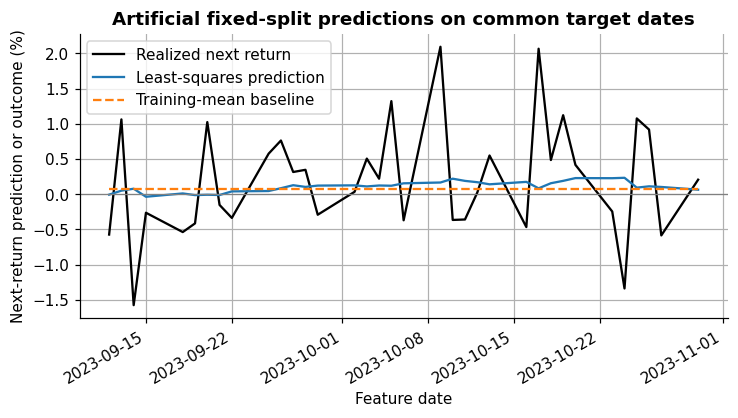

In [22]:
fixed_predictions = pd.concat(
    [fixed_outcome, fixed_linear_prediction, fixed_zero_prediction, fixed_mean_prediction],
    axis=1,
    join="inner",
).dropna()

comparison_rows = []
for method in ["linear_prediction", "zero_prediction", "training_mean_prediction"]:
    prediction = fixed_predictions[method]
    outcome = fixed_predictions["outcome"]
    nonzero = prediction.ne(0.0)
    comparison_rows.append(
        {
            "Method": method,
            "Observations": len(prediction),
            "MSE": np.mean((outcome - prediction) ** 2),
            "MAE": np.mean(np.abs(outcome - prediction)),
            "Nonzero predictions": int(nonzero.sum()),
            "Directional accuracy among nonzero predictions": (
                np.mean(np.sign(prediction[nonzero]) == np.sign(outcome[nonzero])) if nonzero.any() else np.nan
            ),
        }
    )
fixed_metric_comparison = pd.DataFrame(comparison_rows).set_index("Method")
display(fixed_metric_comparison.style.format({"MSE": "{:.8f}", "MAE": "{:.8f}", "Directional accuracy among nonzero predictions": "{:.2%}"}).set_caption("Fixed-split prediction metrics on identical target dates"))

figure, axis = plt.subplots()
preview = fixed_predictions.iloc[:35]
axis.plot(preview.index, 100 * preview["outcome"], label="Realized next return", color="black", linewidth=1.5)
axis.plot(preview.index, 100 * preview["linear_prediction"], label="Least-squares prediction", color="tab:blue")
axis.plot(preview.index, 100 * preview["training_mean_prediction"], label="Training-mean baseline", color="tab:orange", linestyle="--")
axis.axhline(0, color="gray", linewidth=0.8)
axis.set_title("Artificial fixed-split predictions on common target dates")
axis.set_xlabel("Feature date")
axis.set_ylabel("Next-return prediction or outcome (%)")
axis.legend()
figure.autofmt_xdate()
show_figure_with_alt_text(figure, "Line chart of realized artificial next returns, least-squares predictions, and the fixed training-mean baseline for the first 35 common evaluation dates.")

assert fixed_metric_comparison["Observations"].nunique() == 1
assert fixed_metric_comparison["Observations"].iloc[0] == 99
assert fixed_predictions.index.equals(fixed_evaluation.index)

### Interpret Code 1


All methods use 99 identical outcomes. The zero baseline has no nonzero predictions, so the chosen directional statistic remains missing rather than assigning ties silently. MSE and MAE may rank methods differently because they weight error sizes differently.

The plot shows that fitted predictions are much smaller than many realized one-session outcomes on this artificial path. A visible match on a few dates is not a statistical or financial conclusion.


### Source-grounded example

Code 2 compares the AAPL least-squares model, zero baseline, and training-mean baseline on the identical chronological evaluation dates.

### Before Code 2

Predict the common AAPL target count and the MSE, MAE, and disclosed sign-agreement result for each method. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [23]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
split_position = int(0.70 * len(aapl_model))
real_train = aapl_model.iloc[:split_position]
real_evaluation = aapl_model.iloc[split_position:]
real_fit = fit_least_squares(real_train)
predictions = {
    "Least squares": pd.Series(predict_least_squares(real_evaluation, real_fit["coefficients"]), index=real_evaluation.index),
    "Zero return": pd.Series(0.0, index=real_evaluation.index),
    "Training mean": pd.Series(real_train[TARGET_COLUMN].mean(), index=real_evaluation.index),
}
outcome = real_evaluation[TARGET_COLUMN]
real_method_comparison = pd.DataFrame(
    [{"Method": name, "Common targets": len(outcome), "MSE": mean_squared_error(outcome, prediction), "MAE": float(np.mean(np.abs(outcome - prediction))), "Sign agreement with zero treated as a tie": float(np.mean(np.sign(prediction) == np.sign(outcome)))} for name, prediction in predictions.items()]
).set_index("Method")
display(real_method_comparison.style.format({"MSE": "{:.8f}", "MAE": "{:.6f}", "Sign agreement with zero treated as a tie": "{:.2%}"}).set_caption("AAPL prediction methods on identical target dates"))
assert real_method_comparison["Common targets"].nunique() == 1

,Common targets,MSE,MAE,Sign agreement with zero treated as a tie
Method,,,,
Least squares,145,0.00021079,0.010392,54.48%
Zero return,145,0.00021354,0.010638,0.69%
Training mean,145,0.00021135,0.010466,60.69%


### Interpret Code 2


All three AAPL methods use the same 145 evaluation targets. Least squares has MSE 0.00021079, MAE 0.010392, and 54.48% sign agreement. The training-mean baseline has MSE 0.00021135, MAE 0.010466, and 60.69% sign agreement. The zero baseline has MSE 0.00021354 and MAE 0.010638; with zero treated as a tie, its sign agreement is 0.69%. Different metrics rank the methods differently, so the primary prediction criterion and tie rule must be stated before inspection.


### Discussion questions

1. One model has the lowest MSE and another has the lowest MAE. Decide whether the course should declare a winner after seeing both. State which criterion had to be fixed earlier and how the unused metric may still be reported without replacing it.
2. A model produces predictions on 99 dates and a baseline on 95 dates. Explain why comparing their separately calculated MSE values can be misleading and construct the common-date rule that both must satisfy.

## Issue 12 — How does an expanding window change the training sample?


An expanding window begins at a fixed historical start and adds each newly observable target. At prediction position $i$, the permitted training feature rows are positions 0 through $i-1$ under the one-step-ahead timing used here.

The training sample grows, so older observations never leave. This may provide more data but can retain conditions that are less representative of a later period. That tradeoff must be evaluated rather than assumed.

The example displays exact training boundaries for three prediction dates before fitting any model.


### Connection to a documented source

Pandas documents expanding windows as calculations whose historical sample grows. In prediction work, the financial design must additionally exclude the current unknown target and record the last training target endpoint at each AAPL prediction date.

Sources: [pandas expanding-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.expanding.html); [pandas shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict how the artificial expanding training count and endpoints change at four prediction positions. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [24]:
expanding_boundary_rows = []
for prediction_position in [80, 81, 100]:
    history = model_data.iloc[:prediction_position]
    expanding_boundary_rows.append(
        {
            "Prediction position": prediction_position,
            "Prediction feature date": model_data.index[prediction_position],
            "Training rows": len(history),
            "First training feature date": history.index[0],
            "Last training feature date": history.index[-1],
            "Last training target end date": model_data.index[prediction_position],
            "Current target included": False,
        }
    )
expanding_boundaries = pd.DataFrame(expanding_boundary_rows)
display(expanding_boundaries.style.hide(axis="index").set_caption("Expanding-window boundaries before selected predictions"))

assert expanding_boundaries["Training rows"].tolist() == [80, 81, 100]
assert not expanding_boundaries["Current target included"].any()

Prediction position,Prediction feature date,Training rows,First training feature date,Last training feature date,Last training target end date,Current target included
80,2023-05-23 00:00:00,80,2023-01-31 00:00:00,2023-05-22 00:00:00,2023-05-23 00:00:00,False
81,2023-05-24 00:00:00,81,2023-01-31 00:00:00,2023-05-23 00:00:00,2023-05-24 00:00:00,False
100,2023-06-20 00:00:00,100,2023-01-31 00:00:00,2023-06-19 00:00:00,2023-06-20 00:00:00,False


### Interpret Code 1


The training counts grow from 80 to 81 to 100. The first training feature date remains fixed, while the last training feature date advances. Its one-step-ahead target ends at the current prediction boundary and is observable at that time.

This table distinguishes available training history from model refit frequency. A model may reuse earlier coefficients between scheduled refits even though more targets have become observable.


### Source-grounded example

Code 2 displays the expanding AAPL training rows and target endpoints at four prediction positions without fitting on the current target.

### Before Code 2

Predict the AAPL expanding-window training counts and endpoints at four named prediction dates. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [25]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
prediction_positions = [80, 140, 260, len(aapl_model) - 1]
expanding_records = []
for position in prediction_positions:
    history = aapl_model.iloc[:position]
    expanding_records.append((str(aapl_model.index[position].date()), len(history), str(history.index.min().date()), str(history.index.max().date()), str(next_stored_date(aapl_raw.index, history.index.max()).date())))
real_expanding_boundaries = pd.DataFrame(expanding_records, columns=["Prediction feature date", "Training rows", "First training feature date", "Last training feature date", "Last training target end date"])
display(real_expanding_boundaries.style.hide(axis="index").set_caption("Expanding AAPL training boundaries at four predictions"))
assert real_expanding_boundaries["Training rows"].is_monotonic_increasing

Prediction feature date,Training rows,First training feature date,Last training feature date,Last training target end date
2023-05-26,80,2023-02-01,2023-05-25,2023-05-26
2023-08-23,140,2023-02-01,2023-08-22,2023-08-23
2024-02-14,260,2023-02-01,2024-02-13,2024-02-14
2024-12-31,481,2023-02-01,2024-12-30,2024-12-31


### Interpret Code 2


The expanding AAPL history begins on 2023-02-01 for every displayed prediction. Training rows grow from 80 on 2023-05-26 to 140, 260, and 481 by 2024-12-31. At each prediction, the last training target ends on the prediction date: for the final example, the last training feature is 2024-12-30 and its target ends 2024-12-31. Growth in row count is the defining change; no older row is discarded.


### Discussion questions

1. At prediction position 150, identify the expanding training rows for one-step and five-step targets. Explain why the same expanding-window label produces different last eligible feature rows when the target horizon changes.
2. An older market condition dominates the growing sample. Propose one validation-stage comparison between expanding and rolling windows and explain why the final test cannot be used repeatedly to choose between them.

## Issue 13 — How does a rolling window limit historical memory?


A rolling window keeps a fixed number of the most recent permitted training rows. At prediction position $i$ with window length 80, training uses positions $i-80$ through $i-1$ once enough history exists.

Older observations leave the sample as new targets arrive. This can adapt to change but uses fewer observations and can make estimates less stable. A rolling window is not automatically more robust or more current in a way that guarantees better predictions.

The window length is a model setting that must be selected before the frozen test is opened.


### Connection to a documented source

Pandas documents rolling windows with a stated window size. The AAPL example interprets the size as a count of usable modeling rows; it does not silently convert that count into calendar days or guarantee a preferable market-regime response.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict how the artificial rolling-window start advances while row count remains fixed. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [26]:
rolling_boundary_rows = []
rolling_window = 80
for prediction_position in [80, 81, 100]:
    history = model_data.iloc[:prediction_position].iloc[-rolling_window:]
    rolling_boundary_rows.append(
        {
            "Prediction position": prediction_position,
            "Prediction feature date": model_data.index[prediction_position],
            "Training rows": len(history),
            "First training position": model_data.index.get_loc(history.index[0]),
            "Last training position": model_data.index.get_loc(history.index[-1]),
            "Last training target end date": model_data.index[prediction_position],
        }
    )
rolling_boundaries = pd.DataFrame(rolling_boundary_rows)
display(rolling_boundaries.style.hide(axis="index").set_caption("Eighty-row rolling-window boundaries"))

assert rolling_boundaries["Training rows"].eq(80).all()
assert rolling_boundaries["First training position"].tolist() == [0, 1, 20]
assert rolling_boundaries["Last training position"].tolist() == [79, 80, 99]

Prediction position,Prediction feature date,Training rows,First training position,Last training position,Last training target end date
80,2023-05-23 00:00:00,80,0,79,2023-05-23 00:00:00
81,2023-05-24 00:00:00,80,1,80,2023-05-24 00:00:00
100,2023-06-20 00:00:00,80,20,99,2023-06-20 00:00:00


### Interpret Code 1


All three training samples contain 80 rows. Their first positions advance from 0 to 1 to 20, while their last positions remain immediately before the prediction row. The target on the last training feature row ends at the current boundary.

The fixed row count assumes equally spaced modeling observations for this artificial design. A real calendar and missing rows require explicit date and availability checks.


### Source-grounded example

Code 2 applies an 80-row rolling AAPL window at the same four prediction positions and records how the first training date advances.

### Before Code 2

Predict whether every displayed AAPL rolling window contains 80 rows and how its first training date advances. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [27]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
window_length = 80
prediction_positions = [80, 140, 260, len(aapl_model) - 1]
rolling_records = []
for position in prediction_positions:
    history = aapl_model.iloc[:position].iloc[-window_length:]
    rolling_records.append((str(aapl_model.index[position].date()), len(history), str(history.index.min().date()), str(history.index.max().date()), str(next_stored_date(aapl_raw.index, history.index.max()).date())))
real_rolling_boundaries = pd.DataFrame(rolling_records, columns=["Prediction feature date", "Training rows", "First training feature date", "Last training feature date", "Last training target end date"])
display(real_rolling_boundaries.style.hide(axis="index").set_caption("Rolling 80-row AAPL training boundaries"))
assert real_rolling_boundaries["Training rows"].eq(window_length).all()
assert real_rolling_boundaries["First training feature date"].nunique() == len(real_rolling_boundaries)

Prediction feature date,Training rows,First training feature date,Last training feature date,Last training target end date
2023-05-26,80,2023-02-01,2023-05-25,2023-05-26
2023-08-23,80,2023-04-28,2023-08-22,2023-08-23
2024-02-14,80,2023-10-19,2024-02-13,2024-02-14
2024-12-31,80,2024-09-06,2024-12-30,2024-12-31


### Interpret Code 2


Every displayed AAPL rolling window contains exactly 80 usable modeling rows. Its first training date advances from 2023-02-01 to 2023-04-28, 2023-10-19, and 2024-09-06 as the prediction date advances. The final window ends with the 2024-12-30 feature whose target becomes observable on 2024-12-31. The number 80 denotes observations here, not 80 calendar days.


### Discussion questions

1. A rolling window contains 80 stored rows but spans 95 calendar days because of holidays and missing observations. Decide whether the design should be described by observations, trading sessions, or calendar time and state what must remain constant across model comparisons.
2. A team tries rolling lengths 20, 40, 80, and 160 on the frozen test and retains 40. Explain how this changes the role of the test period and propose a development-period procedure that records all four attempts.

## Issue 14 — How does walk-forward prediction preserve historical availability?


Walk-forward prediction repeats a historical sequence: identify the permitted training rows, fit or reuse a model, transform the current features with permitted parameters, make one prediction, and later compare it with the target when that target becomes observable.

The function below creates both expanding and 80-row rolling predictions. It refits every five prediction dates. Each row records model version, training-row count, last training feature date, and last training target endpoint.

Between refits, the same coefficients are applied to new point-in-time features. That is a new prediction without a new model version.


### Connection to a documented source

Scikit-learn's `TimeSeriesSplit` illustrates successive chronological training and test indexes. The explicit AAPL walk-forward code additionally records model versions, fitted training rows, and the last target endpoint used for each prediction.

Sources: [scikit-learn TimeSeriesSplit documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html); [NumPy least-squares documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict the artificial walk-forward prediction count, model-version count, and last permitted target endpoint. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [28]:
def walk_forward_predict(frame, minimum_train=80, window=None, refit_every=5):
    if minimum_train < 3:
        raise ValueError("minimum_train must permit an intercept and both features")
    if refit_every < 1:
        raise ValueError("refit_every must be positive")
    if window is not None and window < minimum_train:
        raise ValueError("window cannot be shorter than minimum_train")

    result = pd.DataFrame(index=frame.index)
    result["prediction"] = np.nan
    result["model_version"] = pd.Series(pd.NA, index=frame.index, dtype="Int64")
    result["training_rows"] = pd.Series(pd.NA, index=frame.index, dtype="Int64")
    result["last_training_feature_date"] = pd.NaT
    result["last_training_target_end_date"] = pd.NaT

    beta_current = None
    model_version = 0
    fitted_history = None

    for i in range(minimum_train, len(frame)):
        should_refit = beta_current is None or (i - minimum_train) % refit_every == 0
        if should_refit:
            fitted_history = frame.iloc[:i].copy()
            if window is not None:
                fitted_history = fitted_history.iloc[-window:]
            x_history = np.column_stack([np.ones(len(fitted_history)), fitted_history[feature_columns].to_numpy()])
            y_history = fitted_history[target_column].to_numpy()
            beta_current = np.linalg.lstsq(x_history, y_history, rcond=None)[0]
            model_version += 1

        x_now = np.r_[1.0, frame.iloc[i][feature_columns].to_numpy()]
        result.iloc[i, result.columns.get_loc("prediction")] = x_now @ beta_current
        result.iloc[i, result.columns.get_loc("model_version")] = model_version
        result.iloc[i, result.columns.get_loc("training_rows")] = len(fitted_history)
        result.iloc[i, result.columns.get_loc("last_training_feature_date")] = fitted_history.index[-1]
        last_training_position = frame.index.get_loc(fitted_history.index[-1])
        result.iloc[i, result.columns.get_loc("last_training_target_end_date")] = frame.index[last_training_position + 1]

    return result


expanding_walk = walk_forward_predict(model_data, minimum_train=80, window=None, refit_every=5)
rolling_walk = walk_forward_predict(model_data, minimum_train=80, window=80, refit_every=5)

walk_summary = pd.DataFrame(
    [
        {
            "Design": "Expanding",
            "Predictions": int(expanding_walk["prediction"].notna().sum()),
            "Model versions": int(expanding_walk["model_version"].nunique()),
            "Minimum training rows": int(expanding_walk["training_rows"].dropna().min()),
            "Maximum training rows": int(expanding_walk["training_rows"].dropna().max()),
        },
        {
            "Design": "Rolling 80",
            "Predictions": int(rolling_walk["prediction"].notna().sum()),
            "Model versions": int(rolling_walk["model_version"].nunique()),
            "Minimum training rows": int(rolling_walk["training_rows"].dropna().min()),
            "Maximum training rows": int(rolling_walk["training_rows"].dropna().max()),
        },
    ]
)
display(expanding_walk.dropna().head(8))
display(rolling_walk.dropna().head(8))
display(walk_summary.style.hide(axis="index").set_caption("Walk-forward prediction and model-version counts"))

for result in [expanding_walk, rolling_walk]:
    valid = result["prediction"].notna()
    assert (result.loc[valid, "last_training_feature_date"] < result.index[valid]).all()
    assert (result.loc[valid, "last_training_target_end_date"] <= result.index[valid]).all()
assert walk_summary["Predictions"].eq(179).all()
assert walk_summary["Model versions"].eq(36).all()
assert rolling_walk["training_rows"].dropna().eq(80).all()

,prediction,model_version,training_rows,last_training_feature_date,last_training_target_end_date
Date,,,,,
2023-05-23,-0.001954,1,80,2023-05-22,2023-05-23
2023-05-24,0.000413,1,80,2023-05-22,2023-05-23
2023-05-25,0.000770,1,80,2023-05-22,2023-05-23
2023-05-26,0.001708,1,80,2023-05-22,2023-05-23
2023-05-29,0.000990,1,80,2023-05-22,2023-05-23
2023-05-30,0.001816,2,85,2023-05-29,2023-05-30
2023-05-31,0.002634,2,85,2023-05-29,2023-05-30
2023-06-01,0.002604,2,85,2023-05-29,2023-05-30


,prediction,model_version,training_rows,last_training_feature_date,last_training_target_end_date
Date,,,,,
2023-05-23,-0.001954,1,80,2023-05-22,2023-05-23
2023-05-24,0.000413,1,80,2023-05-22,2023-05-23
2023-05-25,0.000770,1,80,2023-05-22,2023-05-23
2023-05-26,0.001708,1,80,2023-05-22,2023-05-23
2023-05-29,0.000990,1,80,2023-05-22,2023-05-23
2023-05-30,0.002485,2,80,2023-05-29,2023-05-30
2023-05-31,0.003161,2,80,2023-05-29,2023-05-30
2023-06-01,0.002978,2,80,2023-05-29,2023-05-30


Design,Predictions,Model versions,Minimum training rows,Maximum training rows
Expanding,179,36,80,255
Rolling 80,179,36,80,80


### Interpret Code 1


Both designs produce 179 predictions and 36 model versions. The rolling design always uses 80 rows, while the expanding design's recorded training count grows only on refit dates and reaches the most recent fitted history size before the final predictions.

The date assertions confirm that the last training feature precedes the prediction and its target ends no later than the prediction boundary. They do not test future profitability.


### Source-grounded example

Code 2 produces AAPL walk-forward predictions with an expanding history, minimum 80 rows, and refitting every five prediction dates.

### Before Code 2

Predict the AAPL walk-forward prediction count, model-version count, and whether every training endpoint is historically permitted. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [29]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
real_walk = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=None, refit_every=5)
real_walk_summary = pd.Series(
    {
        "predictions": int(real_walk["prediction"].notna().sum()),
        "model versions": int(real_walk["model_version"].nunique()),
        "minimum training rows": int(real_walk["training_rows"].dropna().min()),
        "maximum training rows": int(real_walk["training_rows"].dropna().max()),
        "historically permitted target endpoints": bool((real_walk["last_training_target_end_date"].dropna() <= real_walk.index[real_walk["last_training_target_end_date"].notna()]).all()),
    },
    name="Observed value",
)
display(real_walk.dropna(subset=["prediction"]).head(8)[["prediction", "model_version", "training_rows", "last_training_feature_date", "last_training_target_end_date"]])
display(real_walk_summary.to_frame())
assert bool(real_walk_summary["historically permitted target endpoints"])

,prediction,model_version,training_rows,last_training_feature_date,last_training_target_end_date
Date,,,,,
2023-05-26,0.004664,1.0,80.0,2023-05-25,2023-05-26
2023-05-30,0.002069,1.0,80.0,2023-05-25,2023-05-26
2023-05-31,-0.000219,1.0,80.0,2023-05-25,2023-05-26
2023-06-01,-0.002601,1.0,80.0,2023-05-25,2023-05-26
2023-06-02,-0.002044,1.0,80.0,2023-05-25,2023-05-26
2023-06-05,0.004907,2.0,85.0,2023-06-02,2023-06-05
2023-06-06,0.006813,2.0,85.0,2023-06-02,2023-06-05
2023-06-07,0.008045,2.0,85.0,2023-06-02,2023-06-05


,Observed value
predictions,402
model versions,81
minimum training rows,80
maximum training rows,480
historically permitted target endpoints,True


### Interpret Code 2


The expanding AAPL walk-forward design produces 402 predictions and 81 fitted model versions. Training begins with 80 rows and reaches 480 rows in the final fitted version. Model version 1 is reused for the first five displayed predictions, then version 2 begins on 2023-06-05 with 85 fitted rows. Every recorded last training target endpoint is no later than its prediction feature date, so the displayed historical availability check is `True`.


### Discussion questions

1. Select one row whose model version is reused rather than refitted. Identify the new feature values, unchanged training-end record, and new prediction. Explain why a new prediction does not imply new parameters.
2. Change the target to a five-session return. Describe the exact modification required when assigning `last_training_target_end_date` and explain why retaining the one-step `+1` rule would leak four future intervals.

## Issue 15 — How does model-refit frequency differ from prediction frequency?


A model can produce a new prediction from new features without being refitted. Model-refit frequency controls when coefficients and preprocessing parameters change. Prediction frequency controls when the current model is applied to a new feature row.

The comparison keeps expanding-window history and daily predictions fixed while changing refits from every five to every ten prediction dates. Both outputs contain 179 predictions, but the slower schedule contains fewer model versions.

Refitting more often is not automatically better. It may adapt faster, estimate on only slightly changed samples, increase computation, and create more opportunities for unstable parameters.


### Connection to a documented source

A model may generate a new prediction from new AAPL features while retaining previously fitted parameters. The refit schedule determines when coefficients and fitted preprocessing change; prediction frequency is recorded separately.

Sources: [scikit-learn model-persistence guidance](https://scikit-learn.org/stable/model_persistence.html); [NumPy least-squares documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict which artificial quantities change when refitting every 5 rather than every 10 prediction dates. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [30]:
expanding_refit_10 = walk_forward_predict(model_data, minimum_train=80, window=None, refit_every=10)

refit_comparison = pd.DataFrame(
    [
        {
            "Refit schedule": "Every 5 prediction dates",
            "Predictions": int(expanding_walk["prediction"].notna().sum()),
            "Model versions": int(expanding_walk["model_version"].nunique()),
            "Last recorded training rows": int(expanding_walk["training_rows"].dropna().iloc[-1]),
        },
        {
            "Refit schedule": "Every 10 prediction dates",
            "Predictions": int(expanding_refit_10["prediction"].notna().sum()),
            "Model versions": int(expanding_refit_10["model_version"].nunique()),
            "Last recorded training rows": int(expanding_refit_10["training_rows"].dropna().iloc[-1]),
        },
    ]
)
display(refit_comparison.style.hide(axis="index").set_caption("Same prediction dates with two model-refit schedules"))

version_preview = pd.concat(
    [
        expanding_walk["model_version"].rename("refit_every_5"),
        expanding_refit_10["model_version"].rename("refit_every_10"),
    ],
    axis=1,
).dropna().head(22)
display(version_preview.style.set_caption("Model versions on the first 22 prediction dates"))

assert refit_comparison["Predictions"].eq(179).all()
assert refit_comparison["Model versions"].tolist() == [36, 18]

Refit schedule,Predictions,Model versions,Last recorded training rows
Every 5 prediction dates,179,36,255
Every 10 prediction dates,179,18,250


,refit_every_5,refit_every_10
Date,,
2023-05-23 00:00:00,1,1
2023-05-24 00:00:00,1,1
2023-05-25 00:00:00,1,1
2023-05-26 00:00:00,1,1
2023-05-29 00:00:00,1,1
2023-05-30 00:00:00,2,1
2023-05-31 00:00:00,2,1
2023-06-01 00:00:00,2,1
2023-06-02 00:00:00,2,1


### Interpret Code 1


Both schedules make 179 predictions because each available feature row is scored. Refitting every five dates creates 36 model versions; refitting every ten creates 18. The recorded training count remains fixed between refits even though new outcomes become observable.

The comparison does not choose a schedule. Prediction errors and later portfolio effects must be evaluated on common development dates before the final period is opened.


### Source-grounded example

Code 2 holds daily AAPL prediction dates fixed and compares refitting every five with every ten prediction dates.

### Before Code 2

Predict the AAPL prediction and model-version counts for refit-every-5 and refit-every-10 schedules. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [31]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
real_refit_5 = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=None, refit_every=5)
real_refit_10 = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=None, refit_every=10)
real_refit_comparison = pd.DataFrame(
    [
        ("Refit every 5 prediction dates", int(real_refit_5["prediction"].notna().sum()), int(real_refit_5["model_version"].nunique()), int(real_refit_5["training_rows"].dropna().iloc[-1])),
        ("Refit every 10 prediction dates", int(real_refit_10["prediction"].notna().sum()), int(real_refit_10["model_version"].nunique()), int(real_refit_10["training_rows"].dropna().iloc[-1])),
    ],
    columns=["Schedule", "Predictions", "Model versions", "Training rows in final model version"],
)
display(real_refit_comparison.style.hide(axis="index").set_caption("AAPL prediction frequency held fixed while refit frequency changes"))
assert real_refit_comparison["Predictions"].nunique() == 1

Schedule,Predictions,Model versions,Training rows in final model version
Refit every 5 prediction dates,402,81,480
Refit every 10 prediction dates,402,41,480


### Interpret Code 2


Both AAPL schedules produce 402 daily predictions and end with a model fitted on 480 rows. Refitting every five prediction dates creates 81 model versions; refitting every ten creates 41. Prediction frequency therefore stays fixed while coefficient and preprocessing updates change. The table does not decide which schedule predicts better because no selection metric is evaluated here.


### Discussion questions

1. At a date between refits, a new target has become observable but the coefficients are reused. Decide whether the model record should update its last training date. Explain the difference between currently available history and the history actually used by the current model version.
2. Refitting every date gives the lowest final-period MSE after trying schedules 1, 5, 10, and 20. Explain why the final period has become selection evidence and specify what attempt log and new evaluation boundary are needed.

## Issue 16 — How can signal recalculation occur without model refitting?


Signal recalculation applies a threshold to the current prediction. New point-in-time features can change the prediction and signal even while coefficients remain fixed. The signal-update schedule may also restrict when a new rule output is accepted.

The example compares a signal recalculated on every prediction date with one accepted only every fifth prediction date. Between permitted dates, the slower signal retains its last accepted value. Initial rows remain missing until the first prediction and permitted update exist.

This is still a decision record, not a position ledger. Issue 17 adds the portfolio-rebalance rule.


### Connection to a documented source

Applying a fixed threshold to each current prediction recalculates a signal without necessarily refitting the model. The AAPL example preserves daily predictions, model versions, and accepted-signal dates in separate columns.

Sources: [NumPy conditional-selection documentation](https://numpy.org/doc/stable/reference/generated/numpy.where.html); [pandas forward-fill documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict whether signals can change on artificial dates where model version is unchanged. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [32]:
signal_table = pd.DataFrame(index=model_data.index)
signal_table["prediction"] = expanding_walk["prediction"]
signal_table["daily_signal"] = np.where(
    signal_table["prediction"].isna(),
    np.nan,
    np.where(signal_table["prediction"] > 0, 1.0, 0.0),
)

prediction_order = pd.Series(pd.NA, index=signal_table.index, dtype="Int64")
prediction_dates = signal_table.index[signal_table["prediction"].notna()]
prediction_order.loc[prediction_dates] = np.arange(len(prediction_dates))
signal_update_every_5 = prediction_order.notna() & (prediction_order.astype("Float64") % 5 == 0)
signal_table["signal_update_permitted"] = signal_update_every_5
signal_table["signal_every_5"] = signal_table["daily_signal"].where(signal_update_every_5).ffill()

signal_change_summary = pd.Series(
    {
        "model_versions": int(expanding_walk["model_version"].nunique()),
        "daily_signal_changes": int(signal_table["daily_signal"].dropna().diff().abs().fillna(0).sum()),
        "five_date_signal_changes": int(signal_table["signal_every_5"].dropna().diff().abs().fillna(0).sum()),
        "permitted_signal_updates": int(signal_update_every_5.sum()),
    },
    name="Count",
)
display(signal_table.loc[prediction_dates[:18], ["prediction", "daily_signal", "signal_update_permitted", "signal_every_5"]].style.format({"prediction": "{:.6f}"}).set_caption("Daily prediction with two signal-update schedules"))
display(signal_change_summary.to_frame())

assert signal_table.loc[signal_table["prediction"].isna(), "daily_signal"].isna().all()
assert signal_change_summary["five_date_signal_changes"] <= signal_change_summary["daily_signal_changes"]

,prediction,daily_signal,signal_update_permitted,signal_every_5
Date,,,,
2023-05-23 00:00:00,-0.001954,0.000000,True,0.000000
2023-05-24 00:00:00,0.000413,1.000000,False,0.000000
2023-05-25 00:00:00,0.000770,1.000000,False,0.000000
2023-05-26 00:00:00,0.001708,1.000000,False,0.000000
2023-05-29 00:00:00,0.000990,1.000000,False,0.000000
2023-05-30 00:00:00,0.001816,1.000000,True,1.000000
2023-05-31 00:00:00,0.002634,1.000000,False,1.000000
2023-06-01 00:00:00,0.002604,1.000000,False,1.000000
2023-06-02 00:00:00,0.002033,1.000000,False,1.000000


,Count
model_versions,36
daily_signal_changes,23
five_date_signal_changes,7
permitted_signal_updates,36


### Interpret Code 1


Model versions, daily signal changes, permitted update dates, and five-date signal changes have different counts. A refit can leave the signal unchanged, and a new daily prediction can change the signal without a refit.

On this path, carrying the signal between permitted dates reduces or preserves the number of changes. Another threshold or path could change the relation, so the output is not a universal law.


### Source-grounded example

Code 2 creates a daily AAPL signal from each prediction, then accepts a new signal only every fifth prediction date while leaving model versions unchanged between refits.

### Before Code 2

Predict the number of AAPL daily signal changes, accepted-signal changes, and dates where a signal changes without a refit. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [33]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
real_walk = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=None, refit_every=10)
available = real_walk["prediction"].notna()
real_signal_record = real_walk.loc[available, ["prediction", "model_version"]].copy()
real_signal_record["daily_signal"] = (real_signal_record["prediction"] > 0).astype(float)
accept_mask = np.arange(len(real_signal_record)) % 5 == 0
real_signal_record["accepted_signal"] = real_signal_record["daily_signal"].where(accept_mask).ffill()
daily_change = real_signal_record["daily_signal"].diff().abs().fillna(0).gt(0)
accepted_change = real_signal_record["accepted_signal"].diff().abs().fillna(0).gt(0)
same_version_signal_change = daily_change & real_signal_record["model_version"].eq(real_signal_record["model_version"].shift(1))
example_date = real_signal_record.index[same_version_signal_change][0]
real_signal_summary = pd.Series({"daily predictions": len(real_signal_record), "model versions": int(real_signal_record["model_version"].nunique()), "daily signal changes": int(daily_change.sum()), "accepted-signal changes": int(accepted_change.sum()), "first signal change without refit": str(example_date.date())}, name="Observed value")
display(real_signal_record.loc[example_date - pd.Timedelta(days=5):example_date + pd.Timedelta(days=5)].style.format({"prediction": "{:.6f}"}).set_caption("AAPL signal change while the fitted model version is reused"))
display(real_signal_summary.to_frame())
assert same_version_signal_change.any()

,prediction,model_version,daily_signal,accepted_signal
Date,,,,
2023-05-26 00:00:00,0.004664,1.000000,1.000000,1.000000
2023-05-30 00:00:00,0.002069,1.000000,1.000000,1.000000
2023-05-31 00:00:00,-0.000219,1.000000,0.000000,1.000000
2023-06-01 00:00:00,-0.002601,1.000000,0.000000,1.000000
2023-06-02 00:00:00,-0.002044,1.000000,0.000000,1.000000
2023-06-05 00:00:00,0.004224,1.000000,1.000000,1.000000


,Observed value
daily predictions,402
model versions,41
daily signal changes,24
accepted-signal changes,6
first signal change without refit,2023-05-31


### Interpret Code 2


The AAPL record contains 402 daily predictions from 41 model versions. The daily zero-threshold signal changes 24 times, while accepting a new signal every fifth prediction date produces only six accepted-signal changes. On 2023-05-31, model version 1 is reused, the prediction changes to -0.000219, and the daily signal changes from 1 to 0 while the accepted signal remains 1. This is signal recalculation without model refitting or immediate acceptance.


### Discussion questions

1. Find a date where the model version is unchanged but the daily signal changes. Identify the changed feature row and explain why this is signal recalculation rather than model retraining.
2. A team recalculates predictions daily but accepts signals weekly. Decide which prediction metrics should use daily predictions and which decision record should use weekly accepted signals. Explain why mixing the two date sets would distort either comparison.

## Issue 17 — How does portfolio rebalancing differ from signal updating?


Portfolio rebalancing is the decision to change the held exposure. A current signal can be observed without permitting a position change. Under the Week 4 boundary, the accepted signal after feature date $t$ controls the position for the target return from $t$ to $t+1$.

The example compares a position that follows every daily signal with a position that may change only on every fifth prediction date. Both use the same model predictions and zero threshold. The target is stored on the feature row, so `position_for_next_return` names the exposure for that later interval; an end-date ledger would place that position on the target endpoint.

Costs remain zero in Week 5, but position-change counts anticipate the Week 6 turnover comparison.


### Connection to a documented source

Nasdaq publishes regular-session boundaries, but a portfolio rule still determines when an accepted AAPL signal may change the held position. The example carries the prior position between permitted rebalance dates and postpones execution costs to Week 6.

Sources: [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation); [pandas forward-fill documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict which artificial signal changes are blocked by the rebalance schedule. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [34]:
decision_table = signal_table.copy()
decision_table["daily_position_for_next_return"] = decision_table["daily_signal"]
decision_table["five_date_position_for_next_return"] = decision_table["signal_every_5"]

decision_valid = decision_table["prediction"].notna()
daily_position_changes = decision_table.loc[decision_valid, "daily_position_for_next_return"].diff().abs().fillna(0.0)
five_date_position_changes = decision_table.loc[decision_valid, "five_date_position_for_next_return"].diff().abs().fillna(0.0)

rebalance_summary = pd.Series(
    {
        "prediction_dates": int(decision_valid.sum()),
        "daily_position_changes": int(daily_position_changes.sum()),
        "five_date_position_changes": int(five_date_position_changes.sum()),
        "daily_long_target_intervals": int(decision_table.loc[decision_valid, "daily_position_for_next_return"].sum()),
        "five_date_long_target_intervals": int(decision_table.loc[decision_valid, "five_date_position_for_next_return"].sum()),
    },
    name="Count",
)
display(decision_table.loc[prediction_dates[:20], ["prediction", "daily_signal", "daily_position_for_next_return", "signal_update_permitted", "five_date_position_for_next_return"]].style.format({"prediction": "{:.6f}"}).set_caption("Predictions, signals, and positions for the later target interval"))
display(rebalance_summary.to_frame())

assert rebalance_summary["five_date_position_changes"] <= rebalance_summary["daily_position_changes"]
assert decision_table.loc[decision_valid, "daily_position_for_next_return"].isin([0.0, 1.0]).all()

,prediction,daily_signal,daily_position_for_next_return,signal_update_permitted,five_date_position_for_next_return
Date,,,,,
2023-05-23 00:00:00,-0.001954,0.000000,0.000000,True,0.000000
2023-05-24 00:00:00,0.000413,1.000000,1.000000,False,0.000000
2023-05-25 00:00:00,0.000770,1.000000,1.000000,False,0.000000
2023-05-26 00:00:00,0.001708,1.000000,1.000000,False,0.000000
2023-05-29 00:00:00,0.000990,1.000000,1.000000,False,0.000000
2023-05-30 00:00:00,0.001816,1.000000,1.000000,True,1.000000
2023-05-31 00:00:00,0.002634,1.000000,1.000000,False,1.000000
2023-06-01 00:00:00,0.002604,1.000000,1.000000,False,1.000000
2023-06-02 00:00:00,0.002033,1.000000,1.000000,False,1.000000


,Count
prediction_dates,179
daily_position_changes,23
five_date_position_changes,7
daily_long_target_intervals,140
five_date_long_target_intervals,139


### Interpret Code 1


The position-change counts differ from model-version and signal-update counts. A new model does not require a trade; a changed daily signal does not require a trade when the five-date rebalance rule forbids one.

These positions are aligned to next-return targets. Multiplying them by the asset return that already ended on the feature date would recreate Week 4's invalid same-period error.


### Source-grounded example

Code 2 applies the daily AAPL signal but permits position changes only every tenth prediction date, keeping the daily signal and held position separate.

### Before Code 2

Predict the AAPL counts of daily signal changes, permitted position changes, and one date where they differ. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [35]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
real_walk = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=None, refit_every=10)
available = real_walk["prediction"].notna()
real_rebalance = real_walk.loc[available, ["prediction", "model_version"]].copy()
real_rebalance["daily_signal"] = (real_rebalance["prediction"] > 0).astype(float)
rebalance_mask = np.arange(len(real_rebalance)) % 10 == 0
real_rebalance["position_for_later_target"] = real_rebalance["daily_signal"].where(rebalance_mask).ffill()
real_rebalance["position_change"] = real_rebalance["position_for_later_target"].diff().fillna(real_rebalance["position_for_later_target"]).abs()
daily_change = real_rebalance["daily_signal"].diff().abs().fillna(0).gt(0)
blocked_change = daily_change & ~pd.Series(rebalance_mask, index=real_rebalance.index)
example_date = real_rebalance.index[blocked_change][0]
real_rebalance_summary = pd.Series({"daily signal changes": int(daily_change.sum()), "permitted position changes": int(real_rebalance["position_change"].gt(0).sum()), "first signal change without permitted rebalance": str(example_date.date()), "position on that date": real_rebalance.loc[example_date, "position_for_later_target"]}, name="Observed value")
display(real_rebalance.loc[example_date - pd.Timedelta(days=5):example_date + pd.Timedelta(days=5)].style.format({"prediction": "{:.6f}"}).set_caption("AAPL daily signal and position carried between rebalance dates"))
display(real_rebalance_summary.to_frame())
assert (real_rebalance.loc[~pd.Series(rebalance_mask, index=real_rebalance.index), "position_change"] == 0).all()

,prediction,model_version,daily_signal,position_for_later_target,position_change
Date,,,,,
2023-05-26 00:00:00,0.004664,1.000000,1.000000,1.000000,1.000000
2023-05-30 00:00:00,0.002069,1.000000,1.000000,1.000000,0.000000
2023-05-31 00:00:00,-0.000219,1.000000,0.000000,1.000000,0.000000
2023-06-01 00:00:00,-0.002601,1.000000,0.000000,1.000000,0.000000
2023-06-02 00:00:00,-0.002044,1.000000,0.000000,1.000000,0.000000
2023-06-05 00:00:00,0.004224,1.000000,1.000000,1.000000,0.000000


,Observed value
daily signal changes,24
permitted position changes,5
first signal change without permitted rebalance,2023-05-31
position on that date,1.0


### Interpret Code 2


The daily AAPL signal changes 24 times, but the every-tenth-date rebalance rule permits only five position changes. On 2023-05-31 the daily signal changes to 0, while the held position for the later target remains 1 because rebalancing is not permitted. A turnover calculation must use the position-change column, not the more frequent signal changes. Execution feasibility and costs remain outside Week 5.


### Discussion questions

1. A daily signal changes from 0 to 1 on a date when rebalancing is not permitted. State the current signal, held position for the next return, and next date on which the position may change. Explain which object should appear in a turnover calculation.
2. A student shifts `position_for_next_return` again before multiplying it by `target_next_return` stored on the feature row. Determine which later return is then earned and explain how naming both the feature date and target-end date prevents an extra lag.

## Issue 18 — Which model-version evidence must accompany each prediction?


Two equal predictions can come from different model versions, and two different predictions can come from one reused model. Each row should identify the model version, training-row count, last training feature date, last training target endpoint, prediction, accepted signal, and position for the later target.

This record allows another person to reconstruct what the model knew. It also exposes stale models or unscheduled changes. The record does not need every internal array in the student-facing table, but the code and versioned source must reproduce the coefficients.

Rows before the minimum training history remain explicitly unavailable.


### Connection to a documented source

A model-version record identifies which fitted AAPL parameter state produced each prediction. Code and package versions help reproduction, but they do not replace the training-row count, training endpoint, coefficients, and preprocessing parameters.

Sources: [scikit-learn model-persistence guidance](https://scikit-learn.org/stable/model_persistence.html); [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict which artificial model-version fields must remain constant between refits. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [36]:
model_audit = pd.DataFrame(index=model_data.index)
model_audit["target_end_date"] = raw_model_data.index[
    [raw_model_data.index.get_loc(date) + 1 for date in model_audit.index]
]
model_audit = model_audit.join(expanding_walk)
model_audit["signal"] = signal_table["daily_signal"]
model_audit["position_for_target"] = decision_table["daily_position_for_next_return"]
model_audit["target_outcome"] = model_data[target_column]

first_prediction_position = model_audit["prediction"].first_valid_index()
audit_start = model_audit.index.get_loc(first_prediction_position)
audit_preview = model_audit.iloc[audit_start : audit_start + 12]
display(audit_preview.style.format({"prediction": "{:.6f}", "target_outcome": "{:.6f}"}).set_caption("Row-level model, signal, position, and target record"))

audit_checks = pd.Series(
    {
        "prediction_rows": int(model_audit["prediction"].notna().sum()),
        "model_versions": int(model_audit["model_version"].nunique()),
        "last_training_feature_precedes_prediction": bool((model_audit.dropna(subset=["prediction"])["last_training_feature_date"] < model_audit.dropna(subset=["prediction"]).index).all()),
        "last_training_target_observed_by_prediction": bool((model_audit.dropna(subset=["prediction"])["last_training_target_end_date"] <= model_audit.dropna(subset=["prediction"]).index).all()),
        "target_ends_after_feature_date": bool((model_audit["target_end_date"] > model_audit.index).all()),
    },
    name="Value",
)
display(audit_checks.to_frame())
assert bool(audit_checks["last_training_feature_precedes_prediction"])
assert bool(audit_checks["last_training_target_observed_by_prediction"])
assert bool(audit_checks["target_ends_after_feature_date"])

,target_end_date,prediction,model_version,training_rows,last_training_feature_date,last_training_target_end_date,signal,position_for_target,target_outcome
Date,,,,,,,,,
2023-05-23 00:00:00,2023-05-24 00:00:00,-0.001954,1,80,2023-05-22 00:00:00,2023-05-23 00:00:00,0.000000,0.000000,0.007315
2023-05-24 00:00:00,2023-05-25 00:00:00,0.000413,1,80,2023-05-22 00:00:00,2023-05-23 00:00:00,1.000000,1.000000,0.007866
2023-05-25 00:00:00,2023-05-26 00:00:00,0.000770,1,80,2023-05-22 00:00:00,2023-05-23 00:00:00,1.000000,1.000000,0.006845
2023-05-26 00:00:00,2023-05-29 00:00:00,0.001708,1,80,2023-05-22 00:00:00,2023-05-23 00:00:00,1.000000,1.000000,0.015139
2023-05-29 00:00:00,2023-05-30 00:00:00,0.000990,1,80,2023-05-22 00:00:00,2023-05-23 00:00:00,1.000000,1.000000,-0.000952
2023-05-30 00:00:00,2023-05-31 00:00:00,0.001816,2,85,2023-05-29 00:00:00,2023-05-30 00:00:00,1.000000,1.000000,0.001825
2023-05-31 00:00:00,2023-06-01 00:00:00,0.002634,2,85,2023-05-29 00:00:00,2023-05-30 00:00:00,1.000000,1.000000,-0.001355
2023-06-01 00:00:00,2023-06-02 00:00:00,0.002604,2,85,2023-05-29 00:00:00,2023-05-30 00:00:00,1.000000,1.000000,0.016731
2023-06-02 00:00:00,2023-06-05 00:00:00,0.002033,2,85,2023-05-29 00:00:00,2023-05-30 00:00:00,1.000000,1.000000,0.000068


,Value
prediction_rows,179
model_versions,36
last_training_feature_precedes_prediction,True
last_training_target_observed_by_prediction,True
target_ends_after_feature_date,True


### Interpret Code 1


Within a reused model version, the training count and training-end fields remain fixed while features, predictions, signals, and outcomes may change. At a refit row, the version and training record advance together.

The target endpoint is later than the feature date on every row. This prevents the stored target from being mistaken for a same-time feature.


### Source-grounded example

Code 2 checks that every AAPL model version carries its fitted training boundary, row count, coefficients, and training-only feature parameters.

### Before Code 2

Predict whether the AAPL model version, training rows, training endpoint, coefficients, and preprocessing values are complete and internally consistent. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [37]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
real_walk = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=80, refit_every=5)
version_rows = real_walk.dropna(subset=["prediction"]).groupby("model_version", as_index=False).first()
required_version_columns = ["model_version", "training_rows", "first_training_feature_date", "last_training_feature_date", "last_training_target_end_date", "intercept", "momentum_coefficient", "volatility_coefficient", "momentum_mean", "volatility_mean", "momentum_std", "volatility_std"]
real_version_audit = pd.Series({"model versions": len(version_rows), "required fields": len(required_version_columns), "missing required fields": int(version_rows[required_version_columns].isna().sum().sum()), "training rows constant at 80": bool(version_rows["training_rows"].eq(80).all()), "training endpoints advance": bool(version_rows["last_training_feature_date"].is_monotonic_increasing)}, name="Observed value")
display(version_rows[required_version_columns].head(6).style.format({"intercept": "{:.6f}", "momentum_coefficient": "{:.6f}", "volatility_coefficient": "{:.6f}", "momentum_mean": "{:.6f}", "volatility_mean": "{:.6f}", "momentum_std": "{:.6f}", "volatility_std": "{:.6f}"}).set_caption("First six AAPL rolling model-version records"))
display(real_version_audit.to_frame())
assert real_version_audit["missing required fields"] == 0

,model_version,training_rows,first_training_feature_date,last_training_feature_date,last_training_target_end_date,intercept,momentum_coefficient,volatility_coefficient,momentum_mean,volatility_mean,momentum_std,volatility_std
0,1.000000,80.000000,2023-02-01 00:00:00,2023-05-25 00:00:00,2023-05-26 00:00:00,0.002443,-0.004118,-0.001043,0.012021,0.224022,0.026676,0.026161
1,2.000000,80.000000,2023-02-08 00:00:00,2023-06-02 00:00:00,2023-06-05 00:00:00,0.002174,-0.004401,-0.000956,0.010548,0.223358,0.025027,0.026313
2,3.000000,80.000000,2023-02-15 00:00:00,2023-06-09 00:00:00,2023-06-12 00:00:00,0.002185,-0.004052,-0.001134,0.010715,0.216535,0.024419,0.033243
3,4.000000,80.000000,2023-02-23 00:00:00,2023-06-16 00:00:00,2023-06-20 00:00:00,0.002750,-0.003979,-0.000307,0.012518,0.209332,0.023717,0.035960
4,5.000000,80.000000,2023-03-02 00:00:00,2023-06-26 00:00:00,2023-06-27 00:00:00,0.003250,-0.005539,0.001547,0.014740,0.201518,0.021004,0.036748
5,6.000000,80.000000,2023-03-09 00:00:00,2023-07-03 00:00:00,2023-07-05 00:00:00,0.003062,-0.004623,0.000433,0.014871,0.194958,0.020233,0.036770


,Observed value
model versions,81
required fields,12
missing required fields,0
training rows constant at 80,True
training endpoints advance,True


### Interpret Code 2


The rolling AAPL walk-forward record contains 81 model versions. All 12 required fields are populated, every version uses 80 training rows, and training endpoints advance. For example, version 1 uses features from 2023-02-01 through 2023-05-25 with the last target ending 2023-05-26; version 2 advances the window through 2023-06-02 with the last target ending 2023-06-05. Coefficients and training-only means and standard deviations are stored with each version rather than inferred from the prediction alone.


### Discussion questions

1. A prediction changes but `model_version` does not. Use the record to decide whether this is an error. Identify which changing fields can explain the new prediction without a refit.
2. A model version increases while `last_training_feature_date` and `training_rows` remain unchanged. Decide whether the record is consistent with a genuine refit and list the code or parameter evidence needed to distinguish a redundant refit from an undocumented model change.

## Issue 19 — How is a final test period protected from repeated selection?


Training estimates a model. Validation permits prespecified choices such as feature set, window length, refit schedule, threshold, and rebalance rule. A frozen test is opened only after those choices and the code version are fixed.

If a choice changes after final-test results are inspected, that period becomes used evidence. The correct response is to preserve the earlier result, document the change, and stop calling the period untouched. Renaming the file or rerunning with a new seed does not restore independence.

The dates below are an artificial teaching split. The actual Report 1 common period remains pending until the instructor publishes it.


### Connection to a documented source

White (2000) explains the problem created when evaluation data are reused for selection. The AAPL period labels illustrate a training, validation, and frozen-test design; Week 5 does not implement White's formal Reality Check procedure.

Sources: [White (2000)](https://doi.org/10.1111/1468-0262.00152); [scikit-learn cross-validation guidance](https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict which artificial period may be used for fitting, selection, and one final evaluation. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [38]:
period_design = pd.DataFrame(
    [
        ("Training", model_data.index[0], model_data.index[159], "Estimate model and preprocessing parameters"),
        ("Validation", model_data.index[160], model_data.index[209], "Compare prespecified features, windows, refit, threshold, and rebalance choices"),
        ("Frozen test", model_data.index[210], model_data.index[-1], "Run once after choices and code version are frozen"),
    ],
    columns=["Period role", "First feature date", "Last feature date", "Permitted use"],
)
freeze_record = pd.DataFrame(
    [
        ("Feature columns", "mom_5 and vol_20", "Frozen before test"),
        ("Model", "Least squares with intercept", "Frozen before test"),
        ("Prediction baselines", "Zero and historical mean", "Frozen before test"),
        ("Window candidates", "Expanding and rolling 80", "Choose with validation only"),
        ("Refit candidates", "Every 5 or 10 prediction dates", "Choose with validation only"),
        ("Signal threshold", "0", "Frozen before test"),
        ("Rebalance rule", "Daily or every 5 prediction dates", "Choose with validation only"),
        ("After test is opened", "No method or setting change", "Any change relabels test as used evidence"),
    ],
    columns=["Choice", "Artificial Week 5 setting", "Rule"],
)
display(period_design.style.hide(axis="index").set_caption("Artificial training, validation, and frozen-test roles"))
display(freeze_record.style.hide(axis="index").set_caption("Choices and freeze rules"))

assert period_design.loc[0, "Last feature date"] < period_design.loc[1, "First feature date"]
assert period_design.loc[1, "Last feature date"] < period_design.loc[2, "First feature date"]

Period role,First feature date,Last feature date,Permitted use
Training,2023-01-31 00:00:00,2023-09-11 00:00:00,Estimate model and preprocessing parameters
Validation,2023-09-12 00:00:00,2023-11-20 00:00:00,"Compare prespecified features, windows, refit, threshold, and rebalance choices"
Frozen test,2023-11-21 00:00:00,2024-01-26 00:00:00,Run once after choices and code version are frozen


Choice,Artificial Week 5 setting,Rule
Feature columns,mom_5 and vol_20,Frozen before test
Model,Least squares with intercept,Frozen before test
Prediction baselines,Zero and historical mean,Frozen before test
Window candidates,Expanding and rolling 80,Choose with validation only
Refit candidates,Every 5 or 10 prediction dates,Choose with validation only
Signal threshold,0,Frozen before test
Rebalance rule,Daily or every 5 prediction dates,Choose with validation only
After test is opened,No method or setting change,Any change relabels test as used evidence


### Interpret Code 1


The artificial periods are ordered and nonoverlapping. Feature, model, baseline, window, refit, threshold, and rebalance choices are listed explicitly. Only validation may guide a choice among candidates; the frozen test cannot remain untouched after it influences a revision.

The table is a teaching example, not the official Report 1 date assignment. Students cannot be graded against unannounced common settings.


### Source-grounded example

Code 2 assigns the usable AAPL rows once to training, validation, and frozen-test blocks and states the permitted role of each block.

### Before Code 2

Predict the AAPL training, validation, and frozen-test dates and whether the boundaries are ordered and disjoint. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

In [39]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
n_rows = len(aapl_model)
training_end = int(0.60 * n_rows)
validation_end = int(0.80 * n_rows)
real_periods = pd.DataFrame(
    [
        ("Training", 0, training_end, training_end, str(aapl_model.index[0].date()), str(aapl_model.index[training_end - 1].date()), "Estimate parameters"),
        ("Validation", training_end, validation_end, validation_end - training_end, str(aapl_model.index[training_end].date()), str(aapl_model.index[validation_end - 1].date()), "Compare prespecified choices"),
        ("Frozen test", validation_end, n_rows, n_rows - validation_end, str(aapl_model.index[validation_end].date()), str(aapl_model.index[-1].date()), "Evaluate once after choices and code are frozen"),
    ],
    columns=["Block", "Start position", "Exclusive end position", "Rows", "First feature date", "Last feature date", "Permitted use"],
)
display(real_periods.style.hide(axis="index").set_caption("AAPL training, validation, and frozen-test roles"))
assert real_periods["Rows"].sum() == n_rows
assert real_periods["Start position"].iloc[1:].to_list() == real_periods["Exclusive end position"].iloc[:-1].to_list()

Block,Start position,Exclusive end position,Rows,First feature date,Last feature date,Permitted use
Training,0,289,289,2023-02-01,2024-03-26,Estimate parameters
Validation,289,385,96,2024-03-27,2024-08-13,Compare prespecified choices
Frozen test,385,482,97,2024-08-14,2024-12-31,Evaluate once after choices and code are frozen


### Interpret Code 2


The 482 usable AAPL rows are assigned once: 289 training rows from 2023-02-01 through 2024-03-26, 96 validation rows from 2024-03-27 through 2024-08-13, and 97 frozen-test rows from 2024-08-14 through 2024-12-31. The positions are contiguous and sum to 482. Training estimates parameters, validation compares prespecified choices, and the test is opened once only after those choices and the code version are frozen.


### Discussion questions

1. After opening the frozen test, a team discovers a coding error and corrects it. Explain what versions and results must be preserved, whether the period remains untouched, and how the corrected evidence should be labeled.
2. A team never changes code but selects the best narrative after inspecting five test metrics. Decide whether this is still a form of result-driven selection and specify which primary metric and claim boundary should have been frozen earlier.

## Issue 20 — What can the integrated prediction and decision evidence support?


The integrated comparison combines expanding and rolling walk-forward predictions on common feature dates, applies the same zero threshold, assumes a position update is permitted on every prediction date, aligns each resulting long-or-cash position with the later target return, and reports gross wealth before costs. Prediction MSE and gross wealth answer different questions.

With the stated zero threshold and daily position-update permission, $s_t=1$ when $\widehat y_t>0$ and $s_t=0$ otherwise, and the position for the later target interval equals $s_t$. Under the Week 4 long-or-cash rule and zero cash return, the displayed gross endpoint is

$$
W_T
=
\prod_{t=1}^{T}\left(1+s_t y_t\right).
$$

This expression omits execution costs and does not replace the separate prediction-loss calculation.

The comparison uses the same target dates and position rule for both methods. It does not select a preferred method from this artificial path, and it does not call gross wealth a complete performance measure.

Week 6 must add common costs, execution delay, and financial benchmarks. Week 7 must add return, risk, drawdown, turnover, uncertainty, and backtest-validity evidence.


### Connection to a documented source

The same AAPL targets are used to compare expanding and rolling predictions and the positions produced by one fixed threshold. Prediction loss and gross wealth answer different questions, and neither includes the Week 6 costs or Week 7 risk and uncertainty evidence.

Sources: [scikit-learn mean-squared-error documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html); [pandas cumulative-product documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.cumprod.html).

### Controlled example

This first example uses instructor-created data so the target, historical boundary, fitted quantities, and expected result can be checked directly. Its output supports only the displayed artificial calculation.

### Before Code 1

Predict whether lower artificial MSE must imply higher gross terminal wealth. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

,Common targets,MSE,Directional accuracy,Long target intervals,Position changes,Gross terminal wealth before costs
Method,,,,,,
Expanding,179,0.00009390,56.42%,140,23,1.248732
Rolling 80,179,0.00009836,50.28%,131,19,1.111331


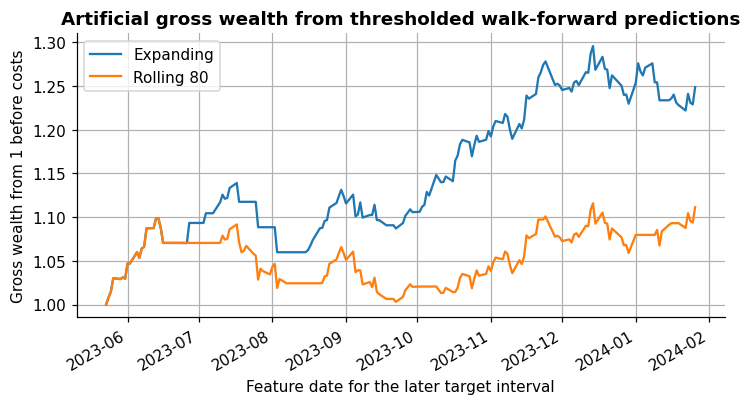

,Value
common_target_count_equal,True
common_target_count,179
all_metrics_finite,True
costs_included,False
result_is_real_market_evidence,False


In [40]:
integrated_rows = []
integrated_paths = {}
for method_name, result in {"Expanding": expanding_walk, "Rolling 80": rolling_walk}.items():
    common = result["prediction"].notna() & model_data[target_column].notna()
    prediction = result.loc[common, "prediction"]
    outcome = model_data.loc[common, target_column]
    signal = (prediction > 0).astype(float)
    gross_return_for_later_target = signal * outcome
    gross_wealth = (1 + gross_return_for_later_target).cumprod()
    integrated_paths[method_name] = gross_wealth
    integrated_rows.append(
        {
            "Method": method_name,
            "Common targets": int(common.sum()),
            "MSE": float(np.mean((outcome - prediction) ** 2)),
            "Directional accuracy": float(np.mean(np.sign(prediction) == np.sign(outcome))),
            "Long target intervals": int(signal.sum()),
            "Position changes": int(signal.diff().abs().fillna(0.0).sum()),
            "Gross terminal wealth before costs": float(gross_wealth.iloc[-1]),
        }
    )
integrated_comparison = pd.DataFrame(integrated_rows).set_index("Method")
display(integrated_comparison.style.format({"MSE": "{:.8f}", "Directional accuracy": "{:.2%}", "Gross terminal wealth before costs": "{:.6f}"}).set_caption("Prediction results and gross wealth from stated positions on common artificial targets"))

figure, axis = plt.subplots()
for method_name, wealth in integrated_paths.items():
    axis.plot(wealth.index, wealth, label=method_name)
axis.set_title("Artificial gross wealth from thresholded walk-forward predictions")
axis.set_xlabel("Feature date for the later target interval")
axis.set_ylabel("Gross wealth from 1 before costs")
axis.legend()
figure.autofmt_xdate()
show_figure_with_alt_text(figure, "Two artificial gross-wealth lines show positions formed from expanding and rolling walk-forward predictions before transaction costs.")

integrated_audit = pd.Series(
    {
        "common_target_count_equal": integrated_comparison["Common targets"].nunique() == 1,
        "common_target_count": int(integrated_comparison["Common targets"].iloc[0]),
        "all_metrics_finite": bool(np.isfinite(integrated_comparison.to_numpy()).all()),
        "costs_included": False,
        "result_is_real_market_evidence": False,
    },
    name="Value",
)
display(integrated_audit.to_frame())
assert bool(integrated_audit["common_target_count_equal"])
assert integrated_audit["common_target_count"] == 179
assert bool(integrated_audit["all_metrics_finite"])

### Interpret Code 1


Both methods use 179 common targets, and all reported values are finite. Their MSE, directional accuracy, exposure history, position changes, and gross wealth need not rank the methods in the same order because thresholding discards prediction magnitude, errors occur on different return sizes, and positions compound over time.

The gross endpoints exclude transaction costs and use artificial outcomes. The only supported conclusions concern the displayed mechanism and fixed path. No method is established as preferable for a real portfolio.


### Source-grounded example

Code 2 compares expanding and rolling AAPL walk-forward predictions on the exact common target dates, then applies one zero threshold and assumes a position update is permitted on every prediction date to form gross pre-cost return paths.

### Before Code 2

Predict the common AAPL target count and whether expanding and rolling methods have the same ranking under MSE and gross terminal wealth. Give a checkable answer before running the cell. Keep the original prediction and add a revision underneath it if the output differs.

,Common targets,MSE,Sign agreement,Long target intervals,Signal-change rows,Gross terminal wealth before costs
Method,,,,,,
Expanding,402,0.00018602,52.99%,363,24,1.354261
Rolling 80,402,0.00019842,52.24%,267,52,1.054426


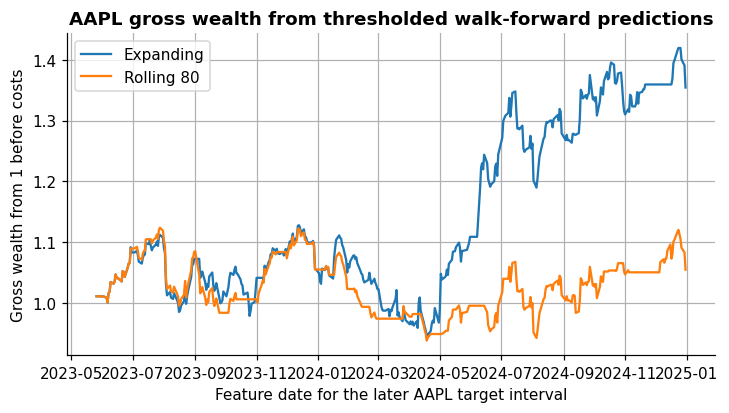

In [41]:
aapl_raw, aapl_model = build_prediction_table("AAPL")
real_expanding = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=None, refit_every=5)
real_rolling = walk_forward_real(aapl_raw, aapl_model, minimum_train=80, window=80, refit_every=5)
common_dates = real_expanding.index[real_expanding["prediction"].notna() & real_rolling["prediction"].notna() & aapl_model[TARGET_COLUMN].notna()]
real_integrated_rows = []
real_integrated_paths = {}
for name, result in {"Expanding": real_expanding, "Rolling 80": real_rolling}.items():
    prediction = result.loc[common_dates, "prediction"]
    outcome = aapl_model.loc[common_dates, TARGET_COLUMN]
    signal = (prediction > 0).astype(float)
    gross_return = signal * outcome
    gross_wealth = (1 + gross_return).cumprod()
    real_integrated_paths[name] = gross_wealth
    real_integrated_rows.append((name, len(common_dates), mean_squared_error(outcome, prediction), float(np.mean(np.sign(prediction) == np.sign(outcome))), int(signal.sum()), int(signal.diff().abs().fillna(0).gt(0).sum()), float(gross_wealth.iloc[-1])))
real_integrated = pd.DataFrame(real_integrated_rows, columns=["Method", "Common targets", "MSE", "Sign agreement", "Long target intervals", "Signal-change rows", "Gross terminal wealth before costs"]).set_index("Method")
display(real_integrated.style.format({"MSE": "{:.8f}", "Sign agreement": "{:.2%}", "Gross terminal wealth before costs": "{:.6f}"}).set_caption("AAPL prediction and gross decision results on common targets"))
figure, axis = plt.subplots()
for name, wealth in real_integrated_paths.items():
    axis.plot(wealth.index, wealth, label=name)
axis.set_title("AAPL gross wealth from thresholded walk-forward predictions")
axis.set_xlabel("Feature date for the later AAPL target interval")
axis.set_ylabel("Gross wealth from 1 before costs")
axis.legend()
show_figure_with_alt_text(figure, "Two lines compare AAPL gross wealth before costs from zero-thresholded expanding and rolling walk-forward predictions on identical target dates.")
assert real_integrated["Common targets"].nunique() == 1

### Interpret Code 2


Both AAPL methods use 402 common targets. Expanding history has MSE 0.00018602, 52.99% sign agreement, 363 long target intervals, 24 signal-change rows, and gross terminal wealth 1.354261 before costs. Rolling 80 has MSE 0.00019842, 52.24% sign agreement, 267 long intervals, 52 signal changes, and gross terminal wealth 1.054426. The expanding method ranks higher on both displayed endpoints in this one sample, but that agreement is contingent rather than necessary; thresholding, return sizes, compounding, and omitted costs can change the portfolio ordering.


### Discussion questions

1. If the lower-MSE method has lower gross wealth, explain at least three row-level mechanisms that can produce the reversal. Decide which evidence belongs in the prediction section and which belongs in the later portfolio section of Report 1.
2. A team chooses rolling 80 because its gross terminal wealth is highest in the frozen test, then reports the same period as final evidence. Explain why this is selection and specify how the period, choice, and conclusion must be relabeled.

# Independent practice issues

The first three exercises isolate timing, window, and update decisions. Case 4 combines the complete Week 5 prediction workflow. Starter cells load new inputs but do not include the requested models, predictions, or conclusions.

## Practice issue 1 — Audit target availability in a fixed split

The starter table contains one feature and a next-row target. Choose a chronological split after the first eight completed targets. For the first evaluation prediction, list every permitted training feature row, the endpoint of the last training target, and the current target that remains unknown.

Fit an intercept-and-one-feature least-squares model on the permitted training block. Compare its predictions with zero and training-mean baselines on the same evaluation targets. Report MSE and the exact target-date intersection without forming a portfolio.

Required checks: the current feature row is excluded from its own training sample; every training target endpoint is no later than the prediction time; and all three methods use identical target dates.

### Discussion questions

1. For the first evaluation prediction, identify the last training feature row, its target endpoint, and the current unknown target endpoint. Explain why adding the current feature row to training would require an unavailable outcome even though its feature is known.
2. Suppose the least-squares model has lower MSE than both baselines but produces the same zero-threshold signal on every evaluation date. State the prediction conclusion supported by the output and the portfolio conclusion that cannot yet be made.

In [42]:
practice_1_dates = pd.bdate_range("2026-09-01", periods=14)
practice_1 = pd.DataFrame(
    {
        "feature": [0.2, -0.1, 0.3, 0.1, -0.2, -0.3, 0.4, 0.2, -0.1, 0.5, 0.1, -0.4, 0.2, 0.0],
        "target_next_return": [0.01, -0.005, 0.012, 0.004, -0.008, -0.01, 0.015, 0.007, -0.004, 0.018, 0.003, -0.012, 0.006, np.nan],
    },
    index=practice_1_dates,
)
display(practice_1.style.format({"target_next_return": "{:.3%}"}).set_caption("Practice 1 fixed-split input"))
print("Input loaded. Mark target endpoints before fitting the model.")

,feature,target_next_return
2026-09-01 00:00:00,0.200000,1.000%
2026-09-02 00:00:00,-0.100000,-0.500%
2026-09-03 00:00:00,0.300000,1.200%
2026-09-04 00:00:00,0.100000,0.400%
2026-09-07 00:00:00,-0.200000,-0.800%
2026-09-08 00:00:00,-0.300000,-1.000%
2026-09-09 00:00:00,0.400000,1.500%
2026-09-10 00:00:00,0.200000,0.700%
2026-09-11 00:00:00,-0.100000,-0.400%
2026-09-14 00:00:00,0.500000,1.800%


Input loaded. Mark target endpoints before fitting the model.


## Practice issue 2 — Compare expanding and rolling training rows

Use the displayed 18-row table with a minimum history of 8 and rolling window length 8. For prediction positions 8, 9, 12, and 17, list the exact expanding and rolling training positions and the endpoint of the last permitted target.

Fit both models at each requested position and save predictions, training counts, last training feature dates, and last training target endpoints. Do not use the current row's target. Explain one benefit and one limitation of discarding older rows without selecting a method from these four predictions.

Required checks: expanding counts grow; rolling counts remain 8; the last training feature precedes every prediction; and the last training target ends no later than the prediction boundary.

### Discussion questions

1. At prediction position 17, list the exact expanding and rolling training positions and calculate how many old observations the rolling design excludes. State one possible benefit and one possible loss of excluding those observations without choosing a winner from four predictions.
2. Change the target from one session to three sessions. Determine the new last eligible training feature position at prediction position 12, and explain why retaining the one-session boundary would use two target intervals that are not yet observable.

In [43]:
practice_2 = pd.DataFrame(
    {
        "x1": np.linspace(-1.0, 1.0, 18),
        "x2": [0.4, 0.3, 0.5, 0.2, 0.1, 0.0, -0.2, -0.1, 0.1, 0.2, 0.5, 0.4, 0.3, 0.0, -0.3, -0.2, 0.1, 0.2],
        "target_next_return": [0.01, 0.004, 0.012, -0.003, -0.006, -0.002, 0.005, 0.008, 0.003, 0.011, 0.014, 0.006, -0.004, -0.009, -0.005, 0.002, 0.007, 0.009],
    },
    index=pd.bdate_range("2026-10-01", periods=18),
)
display(practice_2.style.format({"target_next_return": "{:.3%}"}).set_caption("Practice 2 window-boundary input"))
print("Input loaded. Build the requested boundaries before fitting either model.")

,x1,x2,target_next_return
2026-10-01 00:00:00,-1.000000,0.400000,1.000%
2026-10-02 00:00:00,-0.882353,0.300000,0.400%
2026-10-05 00:00:00,-0.764706,0.500000,1.200%
2026-10-06 00:00:00,-0.647059,0.200000,-0.300%
2026-10-07 00:00:00,-0.529412,0.100000,-0.600%
2026-10-08 00:00:00,-0.411765,0.000000,-0.200%
2026-10-09 00:00:00,-0.294118,-0.200000,0.500%
2026-10-12 00:00:00,-0.176471,-0.100000,0.800%
2026-10-13 00:00:00,-0.058824,0.100000,0.300%
2026-10-14 00:00:00,0.058824,0.200000,1.100%


Input loaded. Build the requested boundaries before fitting either model.


## Practice issue 3 — Separate model, signal, and rebalance updates

The displayed prediction sequence contains three model versions. Apply a zero threshold to calculate a daily signal. Then permit signal acceptance every third prediction date and portfolio rebalancing every sixth prediction date.

Create separate columns for model version, daily signal, accepted signal, position for the next target, and position change. Explain every count and identify one date where a prediction changes without a model refit and one date where a signal changes without a permitted rebalance.

Required checks: the model version changes only where supplied; missing predictions remain missing signals; positions belong to `{0, 1}` after initialization; and position changes occur only on permitted rebalance dates.

### Discussion questions

1. Identify one date where prediction changes while model version stays constant and one date where the accepted signal changes while rebalancing is not permitted. For each, state which columns may change and which must remain fixed.
2. Compare the counts of model refits, daily signal changes, accepted-signal changes, and position changes. Explain why transaction costs in Week 6 must use changes in held position rather than any of the three earlier counts.

In [44]:
practice_3 = pd.DataFrame(
    {
        "prediction": [np.nan, 0.002, -0.001, 0.003, 0.004, -0.002, -0.003, 0.001, 0.002, -0.001, 0.004, 0.003],
        "model_version": [pd.NA, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3],
    },
    index=pd.bdate_range("2026-11-02", periods=12),
)
display(practice_3.style.format({"prediction": "{:.4f}"}).set_caption("Practice 3 prediction and supplied model-version sequence"))
print("Input loaded. Add signal-acceptance and portfolio-rebalance schedules separately.")

,prediction,model_version
2026-11-02 00:00:00,nan,
2026-11-03 00:00:00,0.0020,1
2026-11-04 00:00:00,-0.0010,1
2026-11-05 00:00:00,0.0030,1
2026-11-06 00:00:00,0.0040,2
2026-11-09 00:00:00,-0.0020,2
2026-11-10 00:00:00,-0.0030,2
2026-11-11 00:00:00,0.0010,2
2026-11-12 00:00:00,0.0020,3
2026-11-13 00:00:00,-0.0010,3


Input loaded. Add signal-acceptance and portfolio-rebalance schedules separately.


## Case 4 — Build a complete chronological prediction and decision record

The case supplies 150 artificial rows containing two point-in-time features and a next-session return target. The last target is missing because its later outcome has not been supplied.

Complete the information listed in the preparation section. Use a minimum history of 60 rows. Implement expanding and 60-row rolling least-squares models, refit every five prediction dates, and compare both with zero and historically permitted mean baselines on common target dates. Save model versions, training counts, last training feature dates, and last training target endpoints.

Apply a prespecified zero threshold and a separate every-five-date portfolio-rebalance rule. Align each accepted position with the later target return, report prediction metrics and gross wealth produced by those positions before costs, and state why neither result is complete investment evidence. Define an artificial training, validation, and frozen-test boundary before comparing candidate settings.

### Discussion questions

1. Select the first test-period prediction. Trace its model version, training rows, last training target endpoint, current features, prediction, accepted signal, held position, and later target return. Identify the exact evidence that rules out use of the current target during fitting.
2. If rolling history has lower validation MSE but expanding history has higher frozen-test gross wealth, decide which choice was permitted before the test opened and which conclusions may be reported afterward. State why changing the selected window after seeing test wealth would consume the test as selection evidence.

In [45]:
case_rng = np.random.default_rng(5050)
case_dates = pd.bdate_range("2025-01-06", periods=150)
case_x1 = case_rng.normal(0.0, 1.0, len(case_dates))
case_x2 = np.sin(np.arange(len(case_dates)) / 9.0) + case_rng.normal(0.0, 0.15, len(case_dates))
case_target = 0.0010 * case_x1 - 0.0007 * case_x2 + case_rng.normal(0.0, 0.008, len(case_dates))
case_target[-1] = np.nan
case_4 = pd.DataFrame({"feature_1": case_x1, "feature_2": case_x2, "target_next_return": case_target}, index=case_dates)
display(case_4.head().style.format("{:.6f}").set_caption("Case 4 artificial point-in-time features and later return target"))
display(case_4.tail().style.format("{:.6f}").set_caption("Case 4 ending rows, including the unavailable final target"))
print("Case input loaded. Preserve the final missing target and build the full historical audit.")

,feature_1,feature_2,target_next_return
2025-01-06 00:00:00,-0.304850,0.124092,-0.004001
2025-01-07 00:00:00,0.168911,0.021155,-0.003982
2025-01-08 00:00:00,1.670361,0.146960,0.021047
2025-01-09 00:00:00,-0.294338,0.020728,0.008525
2025-01-10 00:00:00,-0.208039,0.342713,-0.008547


,feature_1,feature_2,target_next_return
2025-07-28 00:00:00,0.138822,-0.480565,-0.000740
2025-07-29 00:00:00,1.343160,-0.345872,0.004758
2025-07-30 00:00:00,-0.318642,-0.799534,-0.000790
2025-07-31 00:00:00,-0.108441,-0.850000,-0.000931
2025-08-01 00:00:00,-1.446160,-0.602975,nan


Case input loaded. Preserve the final missing target and build the full historical audit.


# Terminology reference

| Term | Meaning used in Week 5 |
|---|---|
| feature date | Date when the point-in-time input row is available |
| target | Later outcome that the model predicts or explains |
| target end date | Boundary at which the later outcome becomes observable |
| fixed split | One earlier training block and one later evaluation block |
| expanding window | Training sample with a fixed start and growing end |
| rolling window | Fixed-length training sample whose start and end advance |
| walk-forward evaluation | Repeated chronological prediction with recorded historical training boundaries |
| model refit | Re-estimation of parameters and fitted preprocessing |
| signal recalculation | Application of a stated threshold or rule to a current prediction |
| portfolio rebalance | Permitted change in held exposure for a later return interval |
| prediction baseline | Transparent numerical comparator evaluated on the same target dates |
| model version | Identifier for one fitted parameter state and its training boundary |
| frozen test | Later period opened only after method and settings are fixed |

These meanings apply to the documented artificial lesson. The common Report 1 data, dates, and settings remain pending until published by the instructor.

# Troubleshooting reference

| Symptom | First check | Safe next action |
|---|---|---|
| Current target appears in training | Training slice endpoint and target horizon | End the training feature rows early enough that every target is observable |
| Model has one extra training row | Last training feature and target-end dates | Remove the current prediction row before fitting |
| Random split has very low error | Calendar order of training and evaluation rows | Reconstruct the historical information sequence before interpreting error |
| Modeling row count differs | First valid lookback and final target | Display missing reasons before dropping or filling |
| `lstsq` returns unstable coefficients | Matrix rank, singular values, units, and duplicate features | Simplify or rescale using training-only parameters before interpretation |
| Evaluation row changes after later data are added | Preprocessing fit rows | Fit every transformation inside the permitted training window |
| Baselines use different observations | Prediction and target indexes | Rebuild the exact common target-date intersection |
| Rolling window grows | Order of `iloc[:i]` and final window slice | Limit the permitted history after excluding the current row |
| Model version changes every date unexpectedly | Refit condition | Separate prediction frequency from parameter refitting |
| Signal changes only on refit dates | Signal calculation input | Apply the current model to each permitted feature date if daily prediction is intended |
| Position changes on a forbidden date | Rebalance mask and carried state | Hold the preceding permitted position until the next rebalance date |
| Final test improves after multiple edits | Experiment and version record | Relabel it as used validation evidence and stop calling it untouched |
| Better MSE is described as better investment performance | Target, threshold, position, cost, and wealth evidence | Report prediction and portfolio results separately |

# Optional extensions and sources

## Optional extensions

These activities are not required for Week 5 completion:

- add an intercept-only fitted baseline and compare it with the fixed training mean;
- store coefficients and singular values for every model version and inspect their variation;
- compare refits every 1, 5, 10, and 20 prediction dates using only the validation block;
- use a five-session target and rewrite every target-availability boundary before fitting; and
- investigate a documented time-series cross-validation design without replacing the required chronological historical reconstruction.

## Official software references

- [`numpy.linalg.lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html) documents least-squares solutions, residuals, matrix rank, and singular values.
- [`pandas.DataFrame.expanding`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.expanding.html) documents expanding-window calculations.
- [`pandas.DataFrame.rolling`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) documents rolling-window calculations.
- [`pandas.DataFrame.shift`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) documents value alignment used for later targets.
- Scikit-learn's [`TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) documents successive chronological training and test indexes. The required Week 5 implementation uses explicit pandas and NumPy code instead.

## Financial, statistical, and market references

- White, H. (2000). [A Reality Check for Data Snooping](https://doi.org/10.1111/1468-0262.00152). *Econometrica, 68*(5), 1097–1126.
- Bergmeir, C., Hyndman, R. J., & Koo, B. (2018). [A note on the validity of cross-validation for evaluating autoregressive time series prediction](https://doi.org/10.1016/j.csda.2017.11.003). *Computational Statistics & Data Analysis, 120*, 70–83.
- The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) defines the historical-request interface and half-open date boundary used for AAPL.
- The [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html) identifies Yahoo Finance as the accessed provider and states the project's research and educational scope.
- [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation) supplies the regular-session boundary used only to connect a prediction made after the Close with a later possible decision and execution event.

White supports the warning about reusing data for selection and evaluation; Week 5 does not implement White's formal procedure. Bergmeir, Hyndman, and Koo show that the validity of cross-validation for time-series prediction depends on the model and error conditions, so the notebook does not claim that every nonchronological design is universally invalid. The required course evidence reconstructs historical financial decisions in chronological order. Official software pages support implementation behavior, yfinance documents the request interface, and the market page supports only the session boundary explicitly identified.

# Completion evidence

## Required submission

Submit this completed notebook or an exported report containing:

1. every worked-example cell with visible table or figure output and passed checks;
2. one written response selected from the two discussion questions for each of Issues 1–20, plus any additional responses designated during class;
3. predictions, completed calculations, revisions, and checks for Practice issues 1–3 and Case 4;
4. the requested evaluation information from the preparation section completed once for Case 4;
5. one prediction conclusion supported by the artificial evidence and at least four investment conclusions it cannot support.

## Completion conditions

Week 5 is complete when another student can:

- identify the feature date, target endpoint, and first date on which each training outcome is observable;
- reconstruct the fixed, expanding, rolling, and walk-forward training rows;
- reproduce the least-squares model, rank record, and transparent prediction baselines;
- confirm that preprocessing and model fitting use only permitted historical rows;
- compare all prediction methods on identical target dates with a disclosed metric and tie rule;
- distinguish model versions, daily predictions, accepted signals, and portfolio rebalance dates;
- align a position with the later target return without reintroducing same-period bias; and
- explain when a final period becomes used selection evidence rather than untouched evidence.

The prediction model, baseline comparison, chronological audit, and separate update schedules provide required preparation for [Report 1](../10/week10_main.md). They do not change report weights or add a grading criterion.

## Exit evidence

Complete these statements:

```text
My prediction target ends at ______ and becomes observable at ______.
The last training feature date for prediction t is ______.
The last training target endpoint permitted at t is ______.
My model is refitted every ______.
My signal is recalculated or accepted every ______.
My portfolio may rebalance every ______.
The frozen test is protected by ______.
My prediction evidence supports ______ but cannot support ______.
```

A chronological prediction record can show how an artificial model behaved on stated target dates. It does not establish realistic execution, net profitability, risk-adjusted superiority, statistical certainty across markets, or future performance.